# Bouncing Ball Plots

d:\code\sire\demo\demo_paper/sire/bouncing_ball/first_bouncing_data.csv
d:\code\sire\demo\demo_paper/mujoco/bouncing_ball/first_bouncing_data.csv
d:\code\sire\demo\demo_paper/drake/bouncing_ball/first_bouncing_data.csv


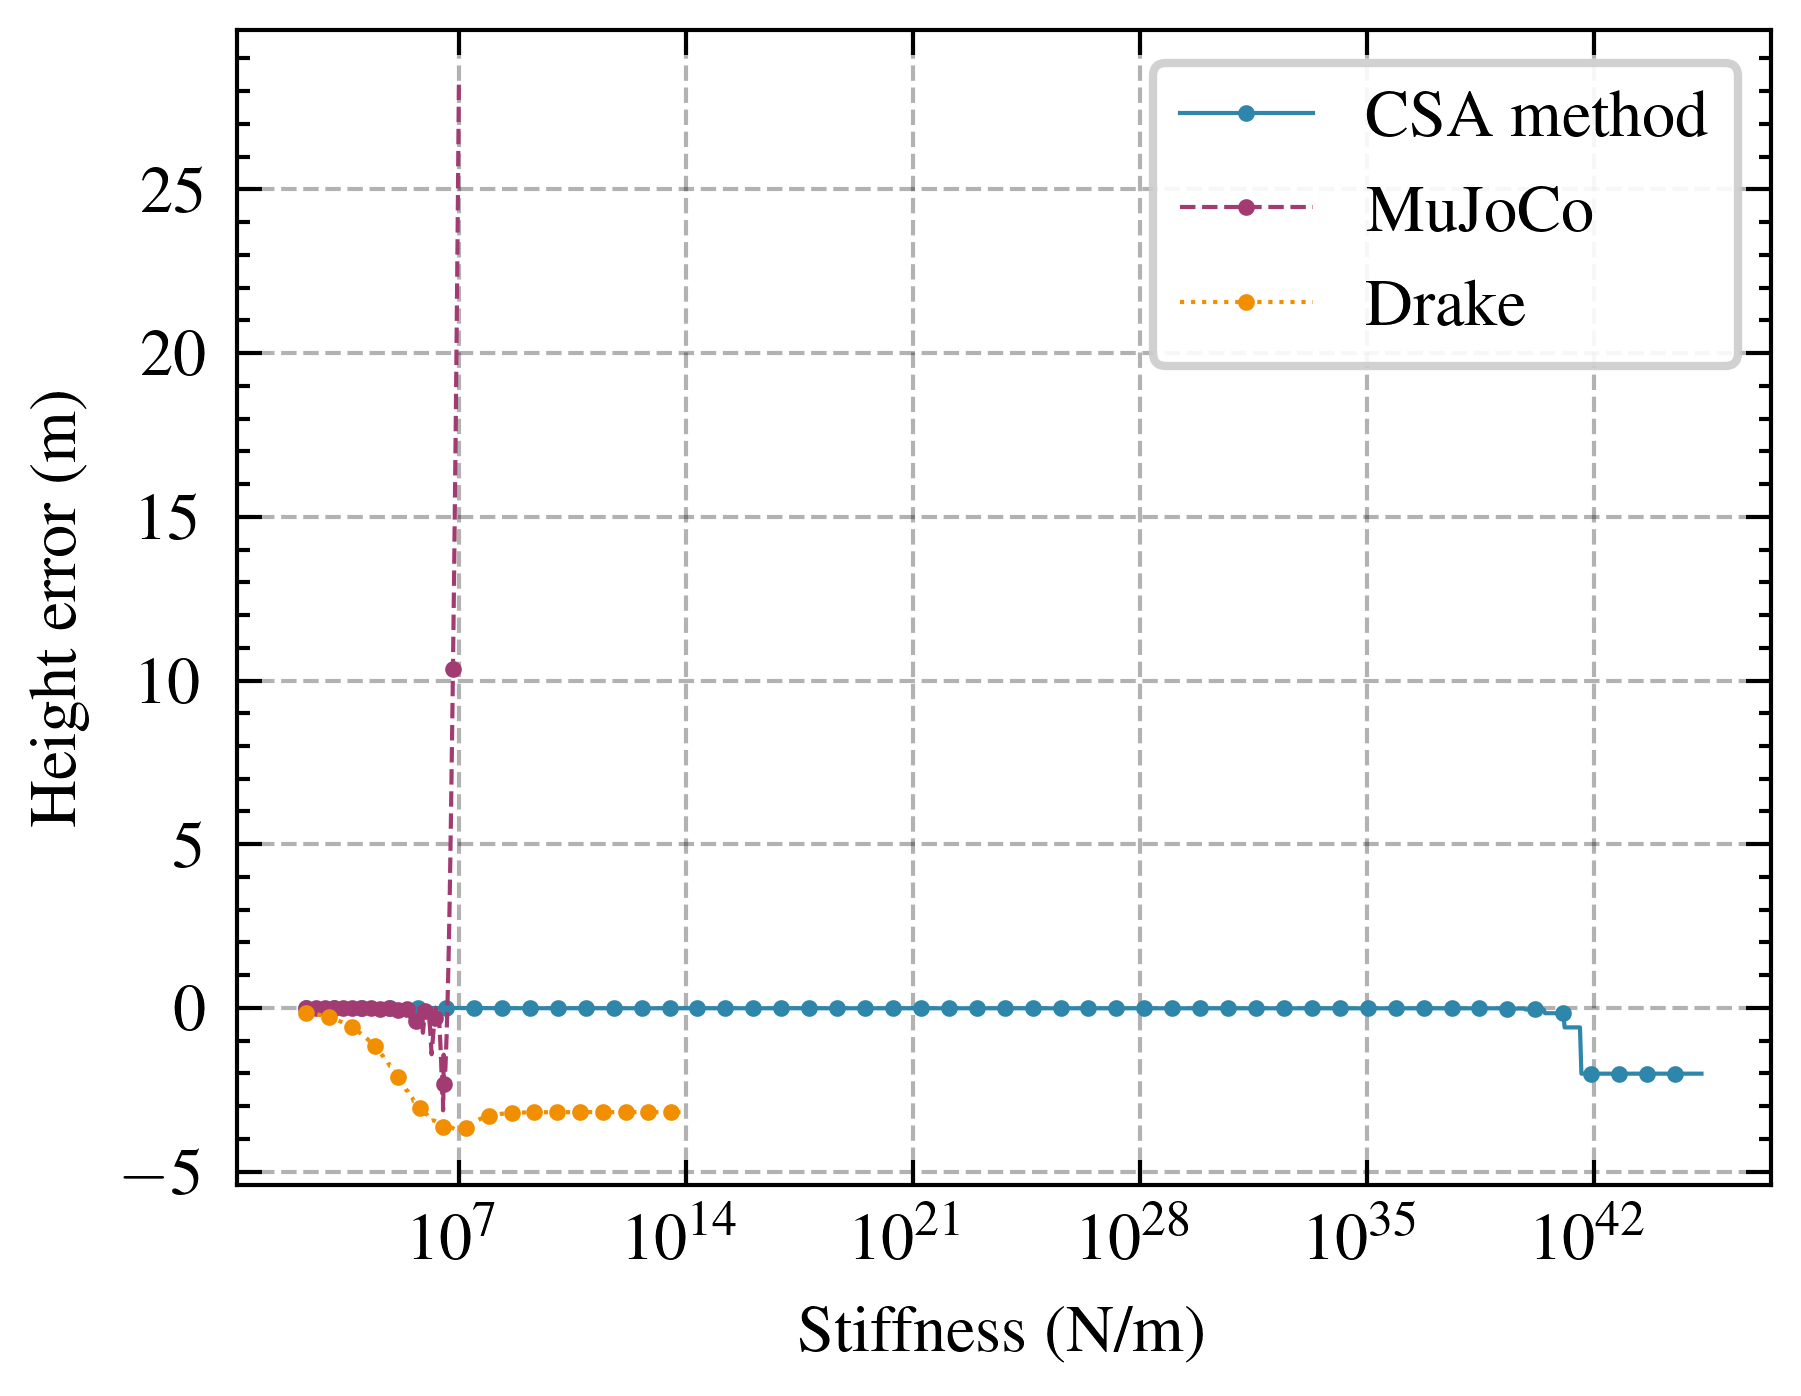

In [2]:
import numpy as np
from os.path import abspath
import os
import matplotlib.pyplot as plt
import scienceplots

firstBouncingPathSire = abspath(os.getcwd()) + "/sire/bouncing_ball/first_bouncing_data.csv"
firstBouncingPathMujoco = abspath(os.getcwd()) + "/mujoco/bouncing_ball/first_bouncing_data.csv"
firstBouncingPathDrake = abspath(os.getcwd()) + "/drake/bouncing_ball/first_bouncing_data.csv"
print(firstBouncingPathSire)
print(firstBouncingPathMujoco)
print(firstBouncingPathDrake)
firstBouncingDataSire = np.genfromtxt(firstBouncingPathSire, delimiter=',', skip_header=1)
firstBouncingDataMujoco = np.genfromtxt(firstBouncingPathMujoco, delimiter=',', skip_header=1)
firstBouncingDataDrake = np.genfromtxt(firstBouncingPathDrake, delimiter=',', skip_header=1)

with plt.style.context(['science','ieee', 'grid']):
  legendStrs = []
  linestyles = ["-", ":", "--", "-."]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  markevery=20
  markersize=1
  linewidth=0.5
  marker='o'
  plt.semilogx(firstBouncingDataSire[:, 0], firstBouncingDataSire[:, 1], label="CSA method", marker=marker, markevery=markevery, markersize=markersize, linewidth=linewidth, color=scientific_colors[0])
  plt.semilogx(firstBouncingDataMujoco[:, 0], firstBouncingDataMujoco[:, 1], label="MuJoCo", marker=marker, markevery=markevery * 3, markersize=markersize, linewidth=linewidth, color=scientific_colors[1])
  plt.semilogx(firstBouncingDataDrake[:, 0], firstBouncingDataDrake[:, 1], label="Drake", marker=marker, markevery=markevery * 3, markersize=markersize, linewidth=linewidth, color=scientific_colors[2])
  # plt.legend(loc="best", fontsize=8)
  plt.legend(framealpha=0.9, loc="upper right")
  # plt.ylim(top=5.5, bottom=-0.5)
  plt.ylabel(r'Height error (m)')
  plt.grid(True, linestyle='--', alpha=0.3)
  plt.xlabel(r'Stiffness (N/m)')
  # plt.title('Bouncing ball by proposed method')
  # plt.grid(True, alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

In [1]:
def binarySearch(timeIndices, time):
  import math
  """
  Binary search to find the index of the closest time
  :param timeIndices: list of time indices
  :param time: target time
  :return: index of the closest time index
  """
  low = 0
  high = len(timeIndices) - 1
  while low < high:
    mid = (low + high) // 2
    # print(low, mid, high, timeIndices[low], timeIndices[mid], timeIndices[high])
    if high - low <= 1:
      return low
    if timeIndices[mid] < time:
      low = mid
    else:
      high = mid
    

def selectXRange(xLower, xUpper, yLower, yUpper, x, y):
  import numpy as np
  # totalFrameNumber = int((max - min) * frameRate)
  xStartIdx = binarySearch(x, xLower)
  xEndIdx = binarySearch(x, xUpper) + 1
  n = xEndIdx - xStartIdx
  resultx = []
  resulty = []

  for i in range(n):
    # currentX = min + i / frameRate
    # currentIdx = binarySearch(x, currentX)
    idx = xStartIdx + i
    if y[idx] >= yLower and y[idx] <= yUpper:
      resultx.append(x[idx])
      resulty.append(y[idx])
  return resultx, resulty

# print(binarySearch(firstBouncingDataDrake[:, 0], 5e6))

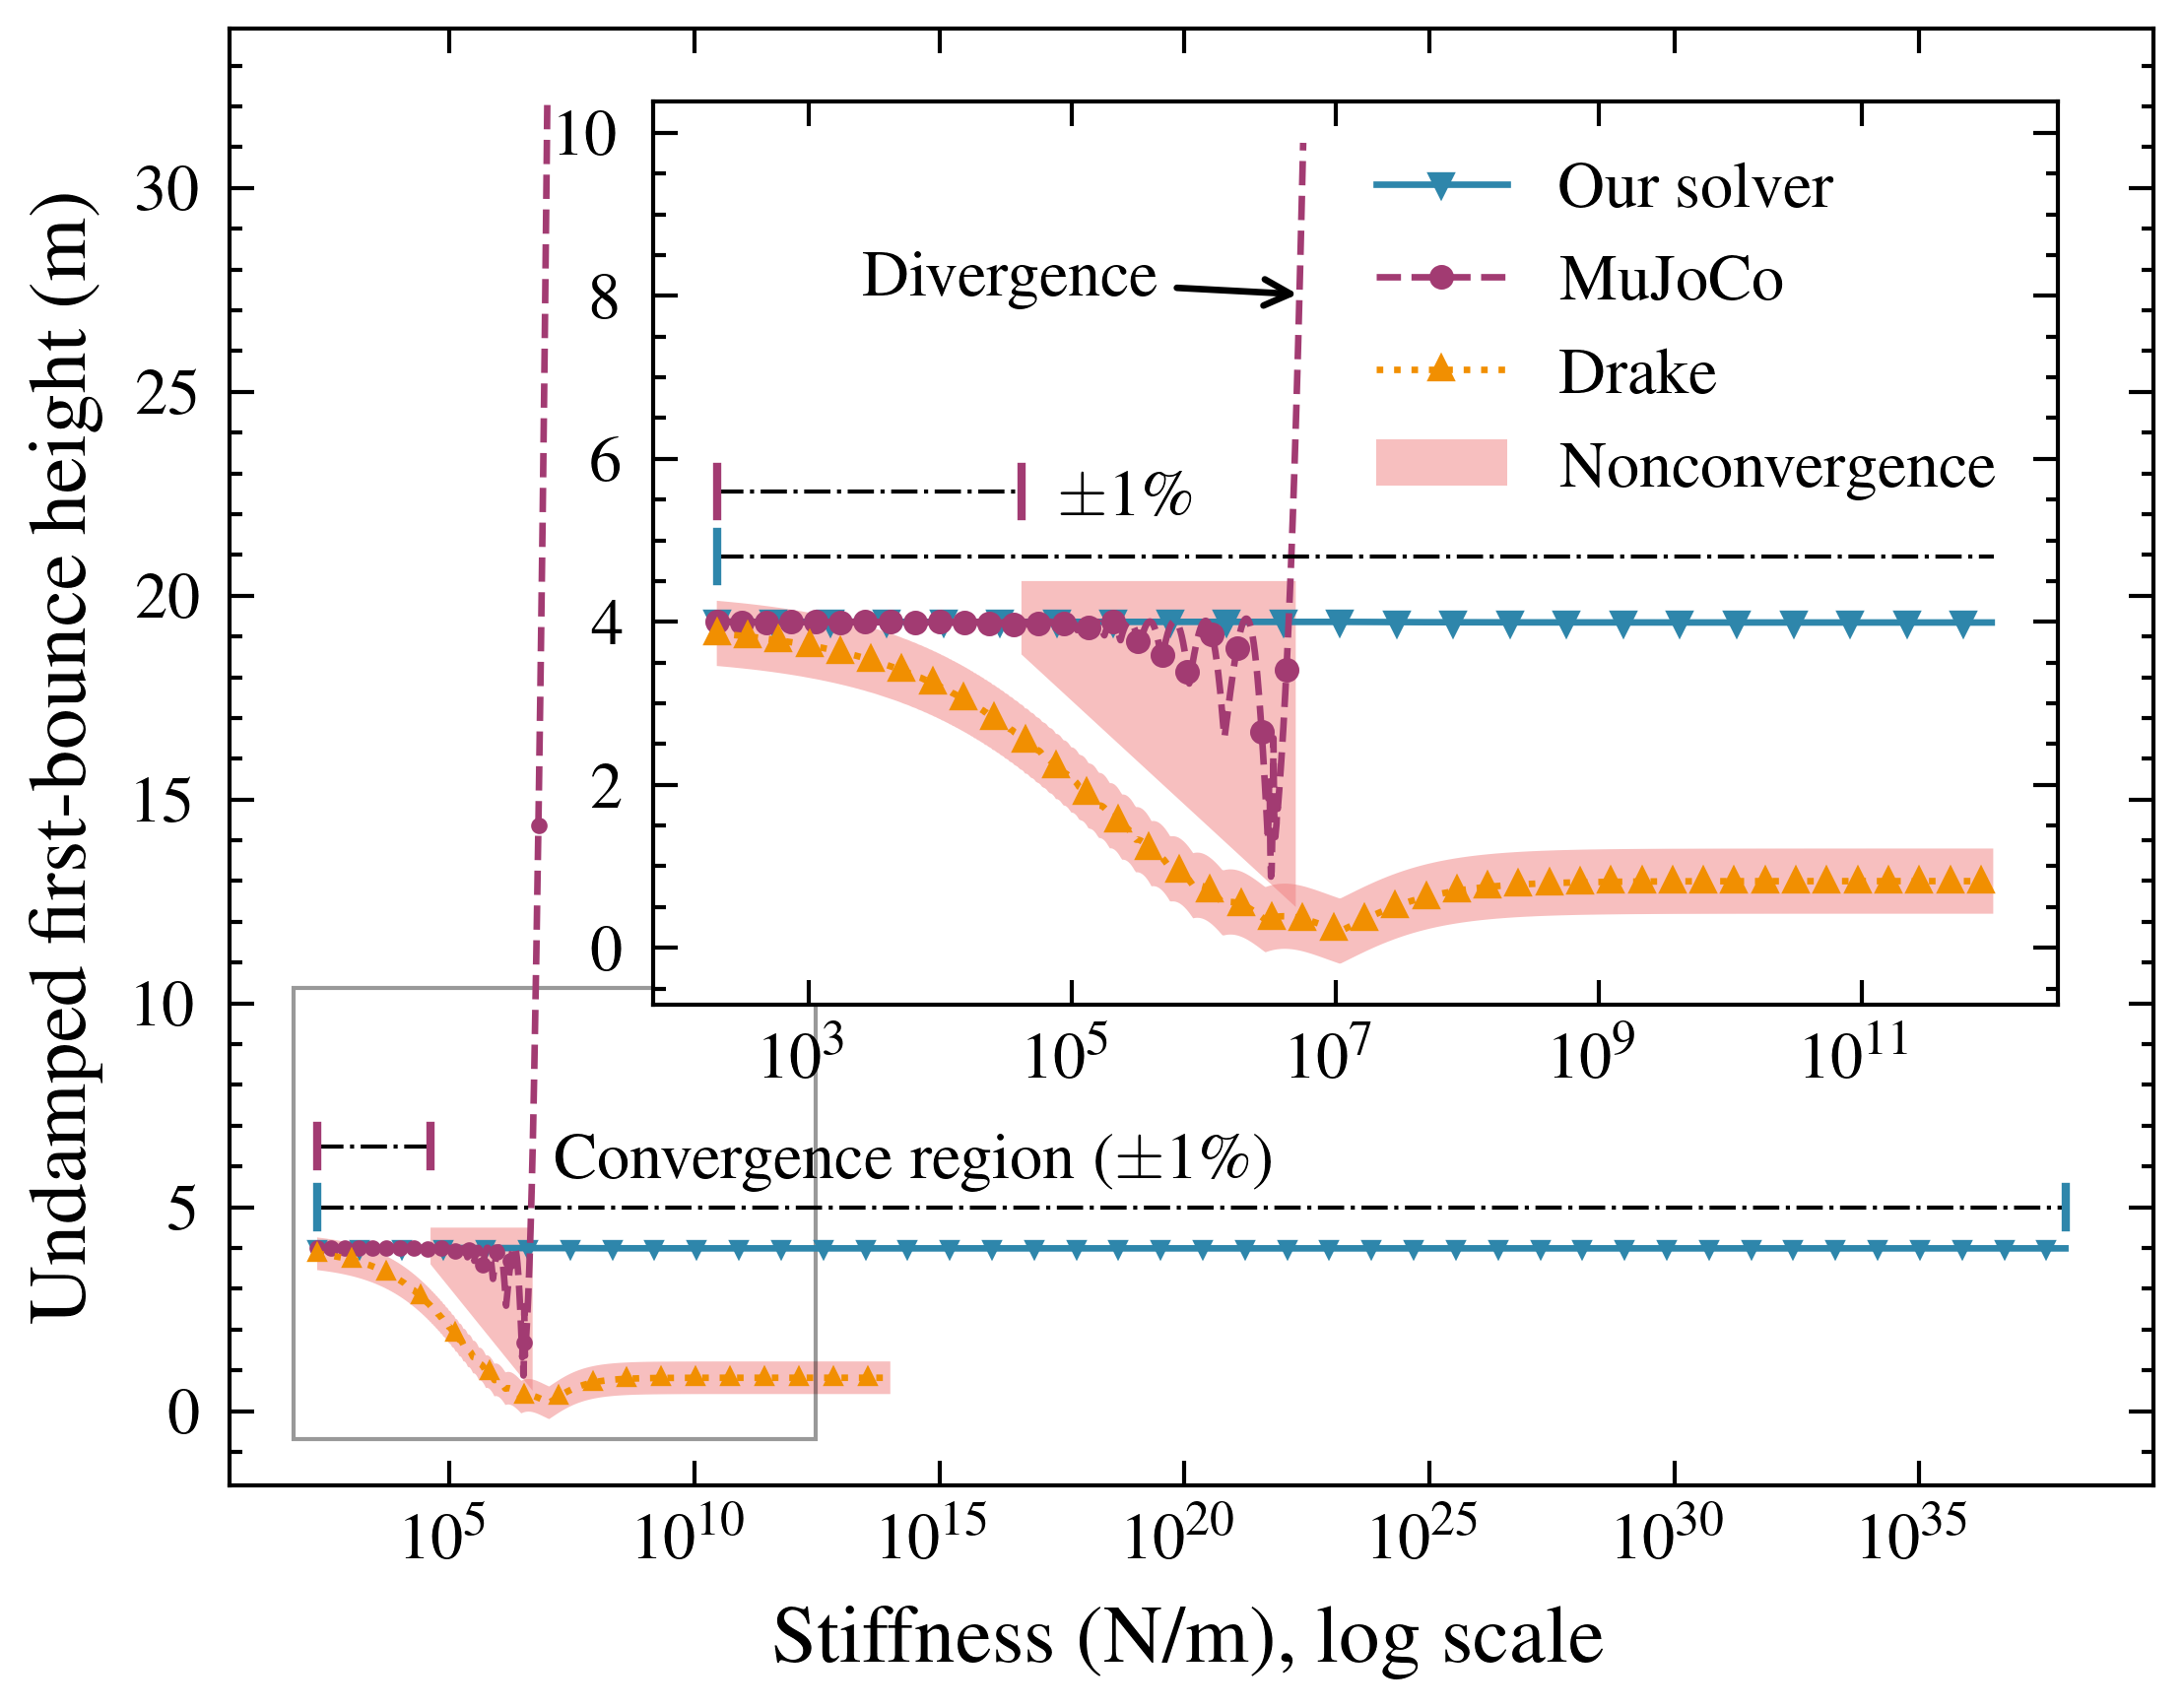

In [2]:
import numpy as np
from os.path import abspath
import os
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.patches import Rectangle
from matplotlib.patches import Polygon
from matplotlib.ticker import LogLocator

def plotBracket(ax, x_left, x_right, y_bracket, cap_height, color, linestyle="-.", linewidth=0.5):
  # horizontal line
  ax.plot([x_left, x_right], [y_bracket, y_bracket], linestyle=linestyle,
          color="black", linewidth=linewidth)

  # left cap
  ax.plot([x_left, x_left],
          [y_bracket - cap_height/2, y_bracket + cap_height/2],
          color=color, linewidth=1, linestyle="-")

  # right cap
  ax.plot([x_right, x_right],
          [y_bracket - cap_height/2, y_bracket + cap_height/2],
          color=color, linewidth=1, linestyle="-")

firstBouncingPathSire = abspath(os.getcwd()) + "/sire/bouncing_ball/first_bouncing_data.csv"
firstBouncingPathMujoco = abspath(os.getcwd()) + "/mujoco/bouncing_ball/first_bouncing_data.csv"
firstBouncingPathDrake = abspath(os.getcwd()) + "/drake/bouncing_ball/first_bouncing_data.csv"
releaseHeight = 4
convergeRate = 0.01
errorBound = releaseHeight * convergeRate
convergeRegion = [releaseHeight - errorBound, releaseHeight + errorBound]
# print(firstBouncingPathSire)
# print(firstBouncingPathMujoco)
# print(firstBouncingPathDrake)
firstBouncingDataSire = np.genfromtxt(firstBouncingPathSire, delimiter=',', skip_header=1)
firstBouncingDataMujoco = np.genfromtxt(firstBouncingPathMujoco, delimiter=',', skip_header=1)
firstBouncingDataDrake = np.genfromtxt(firstBouncingPathDrake, delimiter=',', skip_header=1)
firstBouncingDataSire[:, 1] = firstBouncingDataSire[:, 1] + 4
firstBouncingDataMujoco[:, 1] = firstBouncingDataMujoco[:, 1] + 4
firstBouncingDataDrake[:, 1] = firstBouncingDataDrake[:, 1] + 4
# fontsize = 10
with plt.style.context(['science','ieee']):
  fig, ax = plt.subplots(figsize=(4.2, 3.2))
  legendStrs = []
  linestyles = ["-", ":", "--", "-."]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  markevery=20
  markersize=1
  linewidth=0.8
  marker = ['v', 'o', '^']
  selectedDataSireX, selectedDataSireY = selectXRange(0, 1e38, -10, 10, firstBouncingDataSire[:, 0], firstBouncingDataSire[:, 1])
  ax.semilogx(selectedDataSireX, selectedDataSireY, label="Our solver", marker=marker[0], markevery=markevery, markersize=markersize, linewidth=linewidth, color=scientific_colors[0])
  ax.semilogx(firstBouncingDataMujoco[:, 0], firstBouncingDataMujoco[:, 1], label="MuJoCo", marker=marker[1], markevery=markevery * 3, markersize=markersize, linewidth=linewidth, color=scientific_colors[1])
  ax.semilogx(firstBouncingDataDrake[:, 0], firstBouncingDataDrake[:, 1], label="Drake", marker=marker[2], markevery=markevery * 3, markersize=markersize, linewidth=linewidth, color=scientific_colors[2])

  band_width = 0.4
  ax.fill_between(firstBouncingDataDrake[:, 0], 
                   (firstBouncingDataDrake[:, 1] - band_width).tolist(),
                   (firstBouncingDataDrake[:, 1] + band_width).tolist(),
                   alpha=0.5, color='lightcoral',
                   edgecolor='none', zorder=1)  # zorder 确保在曲线下方
  # Convergence region for Expo
  x_left  = 2e2
  x_right = 1e38
  y_bracket = 5
  cap_height = 1   # 竖线高度
  x_text = (x_left * x_right) ** 0.36  # log-scale center
  ax.text(x_text, y_bracket + 0.4,
        r'Convergence region ($\pm1\%$)',
        ha='center', va='bottom')
  plotBracket(ax, x_left, x_right, y_bracket, cap_height, scientific_colors[0])
  x_left  = 2e2
  x_right = firstBouncingDataMujoco[:, 0][abs(firstBouncingDataMujoco[:, 1] - 4) > errorBound][0]
  y_bracket = 6.5
  cap_height = 1   # 竖线高度
  plotBracket(ax, x_left, x_right, y_bracket, cap_height, scientific_colors[1])
  # x_left  = 1e2
  # x_right = 1e2
  # y_bracket = 6.8
  # cap_height = 1   # 竖线高度
  # plotBracket(ax, x_left, x_right, y_bracket, cap_height, scientific_colors[2])

  ax.set_ylabel(r'Undamped first-bounce height (m)', fontsize=10)
  ax.set_xlabel(r'Stiffness (N/m), log scale', fontsize=10)
  from mpl_toolkits.axes_grid1.inset_locator import inset_axes
  from mpl_toolkits.axes_grid1.inset_locator import mark_inset
  # axins = ax.inset_axes((0.27, 0.27, 0.65, 0.65))
  axins = ax.inset_axes((0.22, 0.33, 0.73, 0.62))
  xStart = 0
  xEnd = 1e12
  yStart = -1
  yEnd = 10
  selectedDataSireX, selectedDataSireY = selectXRange(xStart, xEnd, yStart, yEnd, firstBouncingDataSire[:, 0], firstBouncingDataSire[:, 1])
  selectedDataMujocoX, selectedDataMujocoY = selectXRange(xStart, xEnd, yStart, yEnd, firstBouncingDataMujoco[:, 0], firstBouncingDataMujoco[:, 1])
  selectedDataDrakeX, selectedDataDrakeY = selectXRange(xStart, xEnd, yStart, yEnd, firstBouncingDataDrake[:, 0], firstBouncingDataDrake[:, 1])
  
  axins.semilogx(selectedDataSireX, selectedDataSireY, label="Our solver", marker=marker[0], markersize=2, markevery=10, linewidth=linewidth, color=scientific_colors[0])
  axins.semilogx(selectedDataMujocoX, selectedDataMujocoY, label="MuJoCo", marker=marker[1], markersize=2, markevery=markevery*2, linewidth=linewidth, color=scientific_colors[1])
  axins.semilogx(selectedDataDrakeX, selectedDataDrakeY, label="Drake", marker=marker[2], markersize=2, markevery=markevery, linewidth=linewidth, color=scientific_colors[2])  # linewidth = 0.6
  # 绘制连接线
  connector_x = 5172565.4483902846
  connector_y = 8.019902009898534
  text_x = connector_x - 5.17e6
  text_y = connector_y 
  axins.annotate(
      'Divergence', 
      xycoords='data',
      xy=(connector_x, connector_y), 
      xytext=(text_x, text_y),
      arrowprops=dict(
          arrowstyle='->',
          color="black",
          lw=linewidth,
          shrinkA=0,
          shrinkB=0
      )
  )
  band_width = 0.4
  axins.fill_between(selectedDataDrakeX, 
                   (np.array(selectedDataDrakeY) - band_width).tolist(),
                   (np.array(selectedDataDrakeY) + band_width).tolist(),
                   alpha=0.5, color='lightcoral',
                   edgecolor='none', zorder=1)  # zorder 确保在曲线下方
  x_left  = 2e2
  x_right = 1e12
  y_bracket = 4.8
  cap_height = 0.6   # 竖线高度
  x_text = (x_left * x_right) ** 0.38  # log-scale center
  axins.text(x_text, y_bracket + 0.4,
        r'$\pm1\%$',
        ha='center', va='bottom')
  # horizontal line
  axins.plot([x_left, x_right], [y_bracket, y_bracket], linestyle="-.",
          color="black", linewidth=0.5)
  # left cap
  axins.plot([x_left, x_left],
          [y_bracket - cap_height/2, y_bracket + cap_height/2],
          color=scientific_colors[0], linewidth=1, linestyle="-")
  # axins.text(2e7, 1.5,
  #       r'No converged')
  # ax.text(5e7, 1.8,
  #       r'No converged region')
  rect_low_x, rect_high_x = firstBouncingDataMujoco[:, 0][abs(firstBouncingDataMujoco[:, 1] - 4) > errorBound][0], 5e6
  rect_low_y, rect_high_y = 0.5, 4.5

  rect_width = rect_high_x - rect_low_x
  rect_height = rect_high_y - rect_low_y
  vertices = np.array([
      [rect_low_x, 3.6],  # 左下角 (下底左端点)
      [rect_high_x, rect_low_y],  # 右下角 (下底右端点)
      [rect_high_x, rect_high_y],  # 右上角 (上底右端点)
      [rect_low_x, rect_high_y]   # 左上角 (上底左端点)
  ])

  # 2. 创建并添加梯形补丁
  trapezoid = Polygon(
      vertices,
      closed=True,          # 确保图形是闭合的
      facecolor='lightcoral',  # 填充颜色
      alpha=0.5,           # 透明度
      label='Nonconvergence'
  )
  axins.add_patch(trapezoid)
  trapezoid = Polygon(
      vertices,
      closed=True,          # 确保图形是闭合的
      facecolor='lightcoral',  # 填充颜色
      alpha=0.5,           # 透明度
  )
  ax.add_patch(trapezoid)
  # plotBracket(axins, x_left, x_right, y_bracket, cap_height, scientific_colors[0])
  x_left  = 2e2
  x_right = firstBouncingDataMujoco[:, 0][abs(firstBouncingDataMujoco[:, 1] - 4) > errorBound][0]
  y_bracket = 5.6
  cap_height = 0.6   # 竖线高度
  plotBracket(axins, x_left, x_right, y_bracket, cap_height, scientific_colors[1])
  handles, labels = axins.get_legend_handles_labels()
  # labels[0] = r'$\it{Expo}$' 
  axins.legend(handles, labels, framealpha=0.9, loc="upper right")
  pp, p1, p2 = mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec='k', lw=0.5, alpha=0.5)
  pp.set_alpha(0.4)
  p1.set_alpha(0)
  p2.set_alpha(0)
  plt.savefig("D:/papers/sire_contact_model/res/bouncing_ball_stiffness_range.pdf", format="pdf", dpi=600, bbox_inches='tight')
  plt.show()

## Performance Plots

[0.10162964 0.05951976 0.05422211 0.05691037]
[0.02698413 0.0264584  0.0298377  0.0261456 ]
[0.193917   0.46691811 0.58690446 0.59127985]


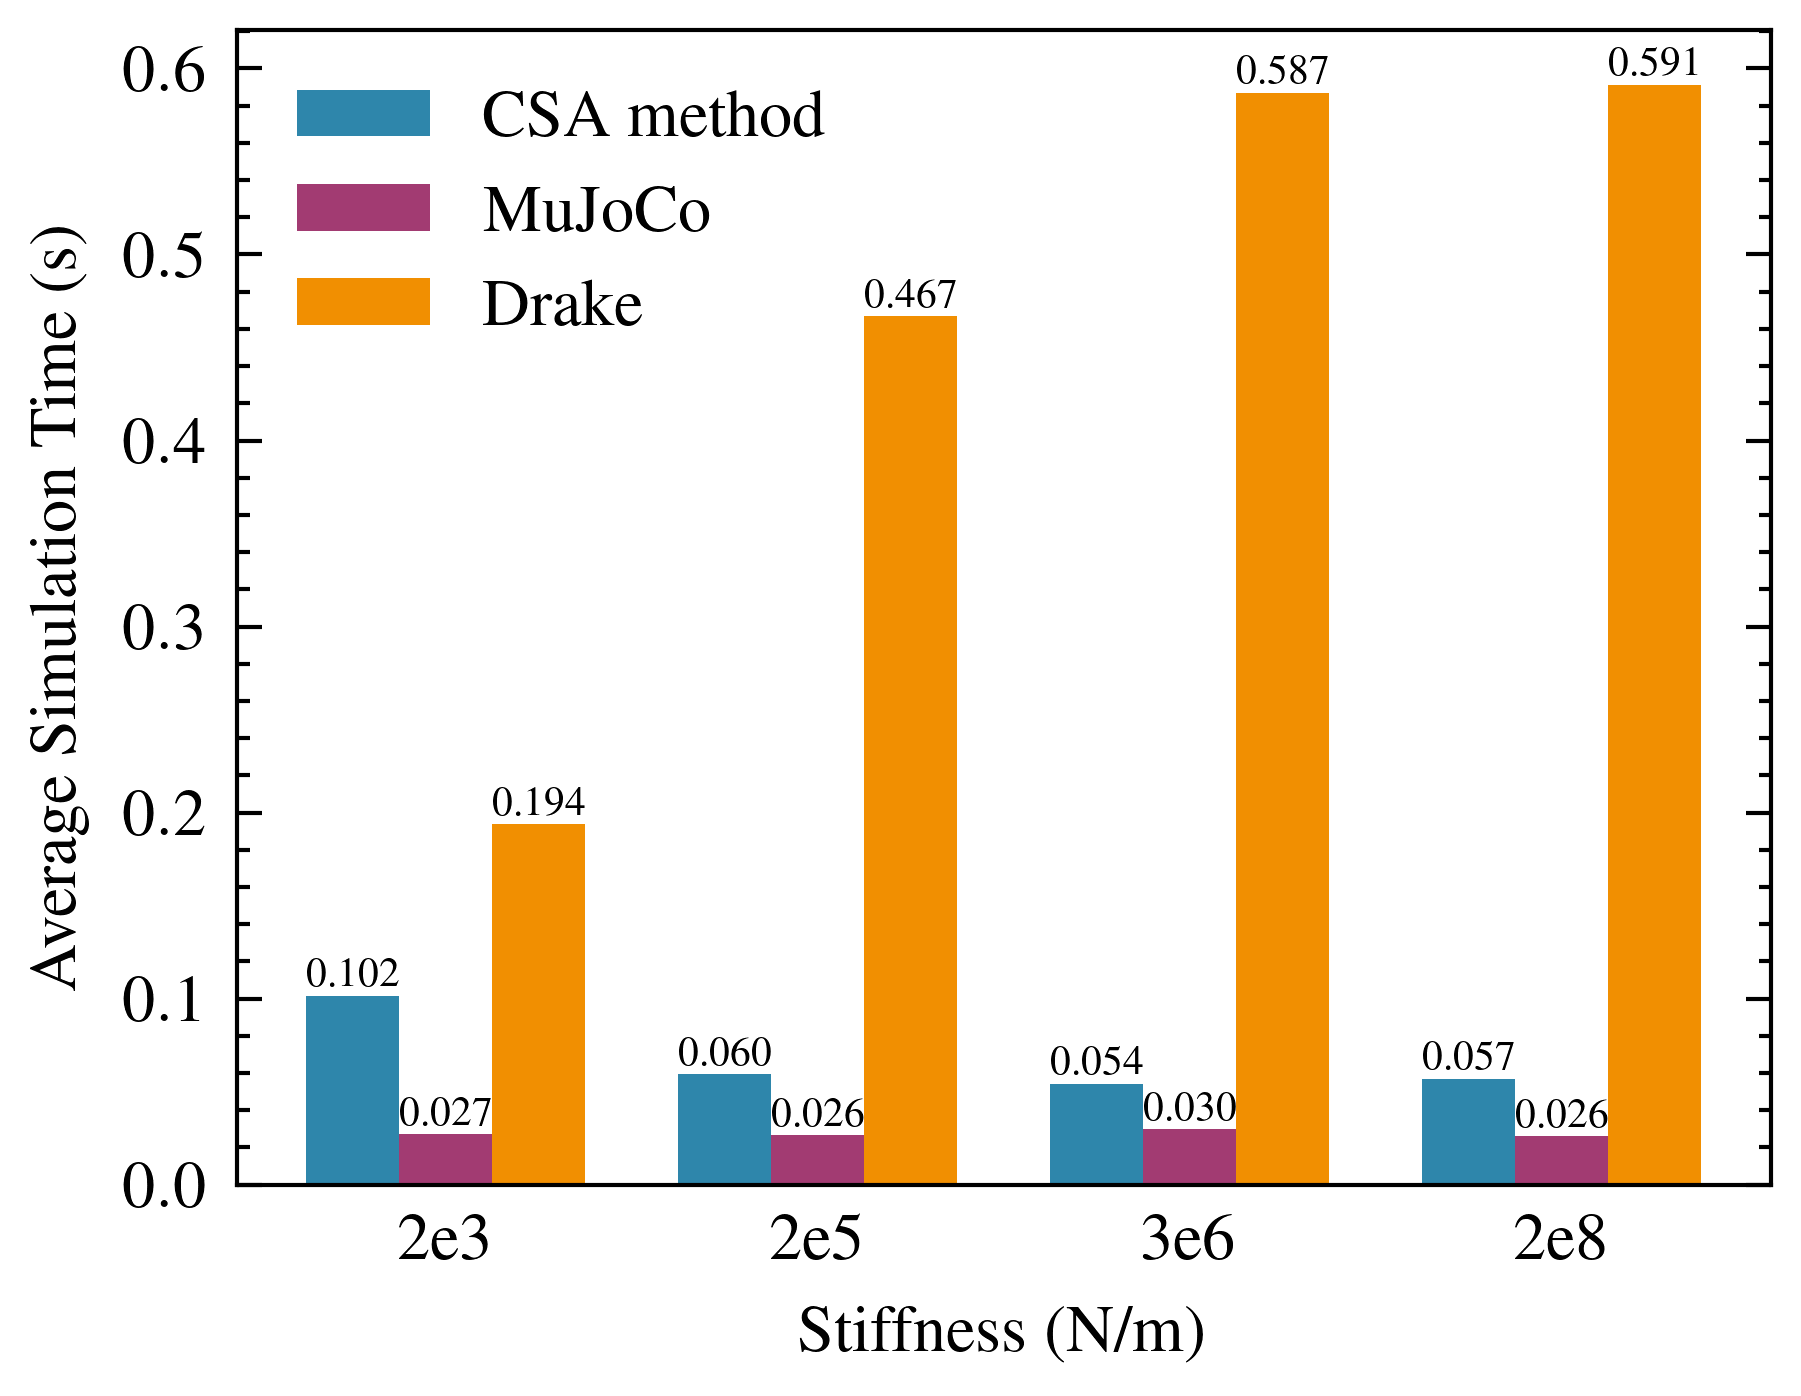

In [16]:
import numpy as np
from os.path import abspath
import os
import matplotlib.pyplot as plt
import scienceplots
perfDataPathSire = abspath(os.getcwd()) + "/sire/bouncing_ball/sire_perf_measure_10s_zero_dissipation.csv"
perfDataPathMujoco = abspath(os.getcwd()) + "/mujoco/bouncing_ball/mujoco_perf_measure_10s_zero_dissipation.csv"
perfDataPathDrake = abspath(os.getcwd()) + "/drake/bouncing_ball/drake_perf_measure_10s_zero_dissipation.csv"
# print(firstBouncingPathSire)
# print(firstBouncingPathMujoco)
# print(firstBouncingPathDrake)
perfDataSire = np.genfromtxt(perfDataPathSire, delimiter=',')
perfDataMujoco = np.genfromtxt(perfDataPathMujoco, delimiter=',')
perfDataDrake = np.genfromtxt(perfDataPathDrake, delimiter=',')
avgSire = np.sum(perfDataSire, 0) / perfDataSire.shape[0]
avgMujoco = np.sum(perfDataMujoco, 0) / perfDataMujoco.shape[0]
avgDrake = np.sum(perfDataDrake, 0) / perfDataDrake.shape[0]
print(avgSire)
print(avgMujoco)
print(avgDrake)
# 使用 SciencePlots 风格
# plt.style.use(['science', 'ieee', 'grid'])
with plt.style.context(['science','ieee']):
  # 参数标签（根据您之前提到的参数）
  parameters = ['2e3', '2e5', '3e6', '2e8']
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  # 设置图形
  # fig, ax = plt.subplots(figsize=(4, 4))
  fig, ax = plt.subplots()

  # 柱状图位置
  x = np.arange(len(parameters))
  width = 0.25

  # 绘制柱状图
  bars1 = ax.bar(x - width, avgSire, width, label='CSA method', color=scientific_colors[0])
  bars2 = ax.bar(x, avgMujoco, width, label='MuJoCo', color=scientific_colors[1])
  bars3 = ax.bar(x + width, avgDrake, width, label='Drake', color=scientific_colors[2])

  # 添加数值标签
  def add_value_labels(bars):
      for bar in bars:
          height = bar.get_height() 
          # height = bar.get_height() * 1.02
          ax.text(bar.get_x() + bar.get_width()/2., height,
                  f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=5)

  add_value_labels(bars1)
  add_value_labels(bars2)
  add_value_labels(bars3)

  # 设置图表属性
  ax.set_xlabel('Stiffness (N/m)')
  ax.set_ylabel('Average Simulation Time (s)')
  # ax.set_title('Comparison of Simulation Platforms: Average Time for 10s Simulation', fontsize=13, pad=15)
  ax.set_xticks(x)
  ax.set_xticklabels(parameters)
  ax.legend()

  # 由于数值范围较大，可以考虑使用对数坐标
  # ax.set_yscale('log')
  # ax.set_ylim(0, 0.00027)
  ax.set_ylabel('Average Simulation Time (s)')
  ax.tick_params(axis='x', which='both', 
               bottom=False,      # 禁用底部刻度
               top=False)         # 禁用顶部刻度  
  # ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

  # 添加网格
  # ax.grid(True, alpha=0.3)

  # 调整布局
  # plt.tight_layout()

  plt.savefig('D:/papers/sire_contact_model/res/bouncing_ball_perf_compare_zero_dissipation.pdf', format="pdf", dpi=300, bbox_inches='tight')
  plt.show()

[0.35671691 0.36794823 0.44184616 0.46081957]
[0.02533467 0.02472246 0.0251807  0.02672652]
[0.69694667 0.68310932 0.70185786 0.80132746]


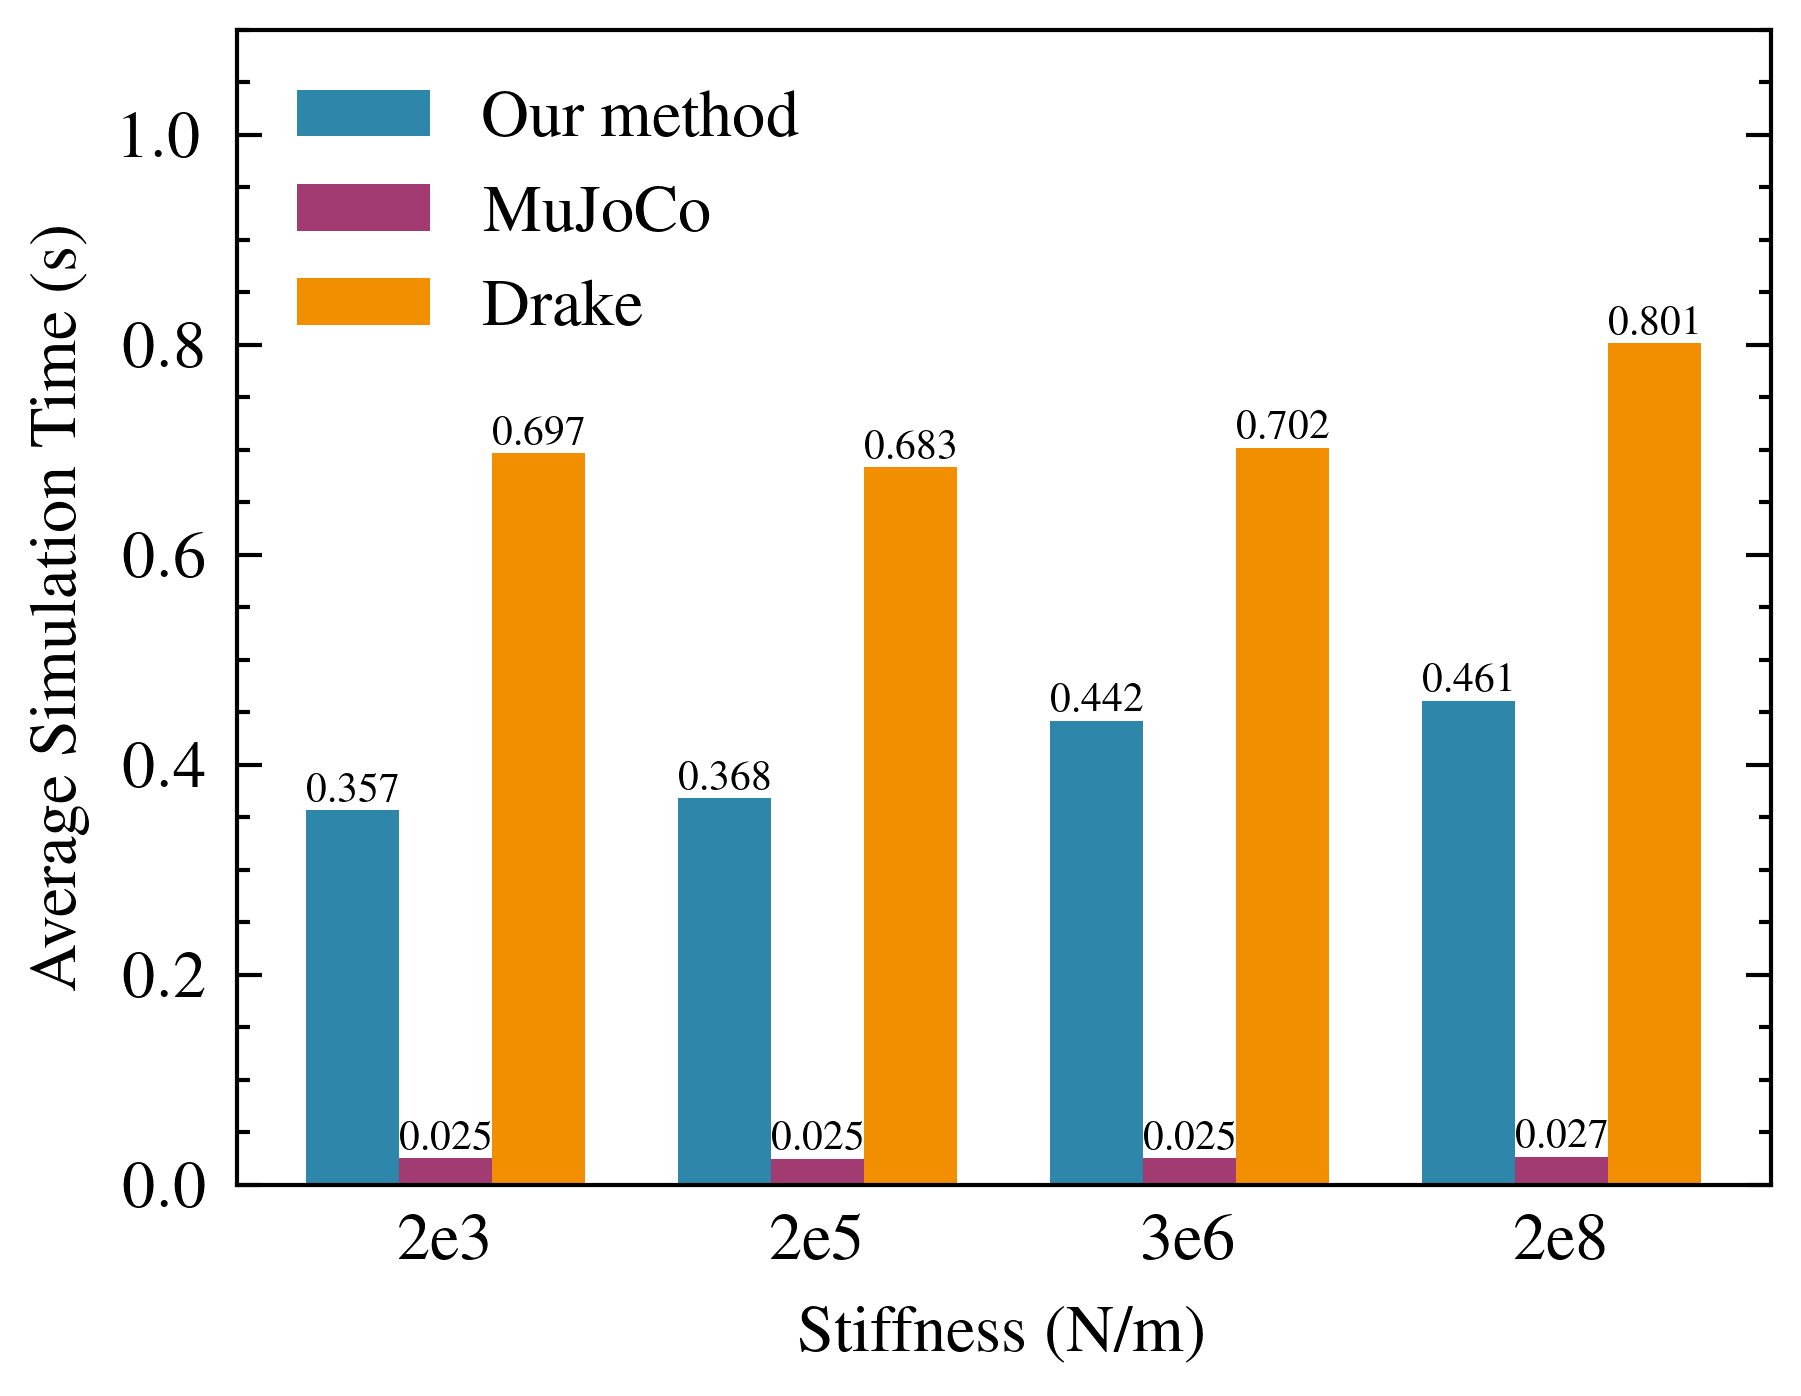

In [ ]:
import numpy as np
from os.path import abspath
import os
import matplotlib.pyplot as plt
import scienceplots
perfDataPathSire = abspath(os.getcwd()) + "/sire/bouncing_ball/sire_perf_measure_10s_high_dissipation.csv"
perfDataPathMujoco = abspath(os.getcwd()) + "/mujoco/bouncing_ball/mujoco_perf_measure_10s_high_dissipation.csv"
perfDataPathDrake = abspath(os.getcwd()) + "/drake/bouncing_ball/drake_perf_measure_10s_high_dissipation.csv"
# print(firstBouncingPathSire)
# print(firstBouncingPathMujoco)
# print(firstBouncingPathDrake)
perfDataSire = np.genfromtxt(perfDataPathSire, delimiter=',')
perfDataMujoco = np.genfromtxt(perfDataPathMujoco, delimiter=',')
perfDataDrake = np.genfromtxt(perfDataPathDrake, delimiter=',')
avgSire = np.sum(perfDataSire, 0) / perfDataSire.shape[0]
avgMujoco = np.sum(perfDataMujoco, 0) / perfDataMujoco.shape[0]
avgDrake = np.sum(perfDataDrake, 0) / perfDataDrake.shape[0]
print(avgSire)
print(avgMujoco)
print(avgDrake)
# 使用 SciencePlots 风格
# plt.style.use(['science', 'ieee', 'grid'])
with plt.style.context(['science','ieee']):
  # 参数标签（根据您之前提到的参数）
  parameters = ['2e3', '2e5', '3e6', '2e8']
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  # 设置图形
  # fig, ax = plt.subplots(figsize=(4, 4))
  fig, ax = plt.subplots()

  # 柱状图位置
  x = np.arange(len(parameters))
  width = 0.25

  # 绘制柱状图
  bars1 = ax.bar(x - width, avgSire, width, label='Our solver', color=scientific_colors[0])
  bars2 = ax.bar(x, avgMujoco, width, label='MuJoCo', color=scientific_colors[1])
  bars3 = ax.bar(x + width, avgDrake, width, label='Drake', color=scientific_colors[2])

  # 添加数值标签
  def add_value_labels(bars):
      for bar in bars:
          height = bar.get_height() 
          # height = bar.get_height() * 1.02
          ax.text(bar.get_x() + bar.get_width()/2., height,
                  f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=5)

  add_value_labels(bars1)
  add_value_labels(bars2)
  add_value_labels(bars3)

  # 设置图表属性
  ax.set_xlabel('Stiffness (N/m)')
  ax.set_ylabel('Average Simulation Time (s)')
  # ax.set_title('Comparison of Simulation Platforms: Average Time for 10s Simulation', fontsize=13, pad=15)
  ax.set_xticks(x)
  ax.set_xticklabels(parameters)
  ax.legend()

  # 由于数值范围较大，可以考虑使用对数坐标
  # ax.set_yscale('log')
  ax.set_ylim(0, 1.1)
  ax.set_ylabel('Average Simulation Time (s)')
  # ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
  ax.tick_params(axis='x', which='both', 
               bottom=False,      # 禁用底部刻度
               top=False)         # 禁用顶部刻度  

  # 添加网格
  # ax.grid(True, alpha=0.3)

  # 调整布局
  # plt.tight_layout()

  plt.savefig('D:/papers/sire_contact_model/res/bouncing_ball_perf_compare_high_dissipation.pdf', format="pdf", dpi=300, bbox_inches='tight')
  plt.show()

[0.00015384 0.00017942 0.00019874 0.00019157]
[2.09715997e-05 1.60533993e-05 1.53667991e-05 1.59274978e-05]
[0.00017363 0.00014746 0.00014868 0.00015132]


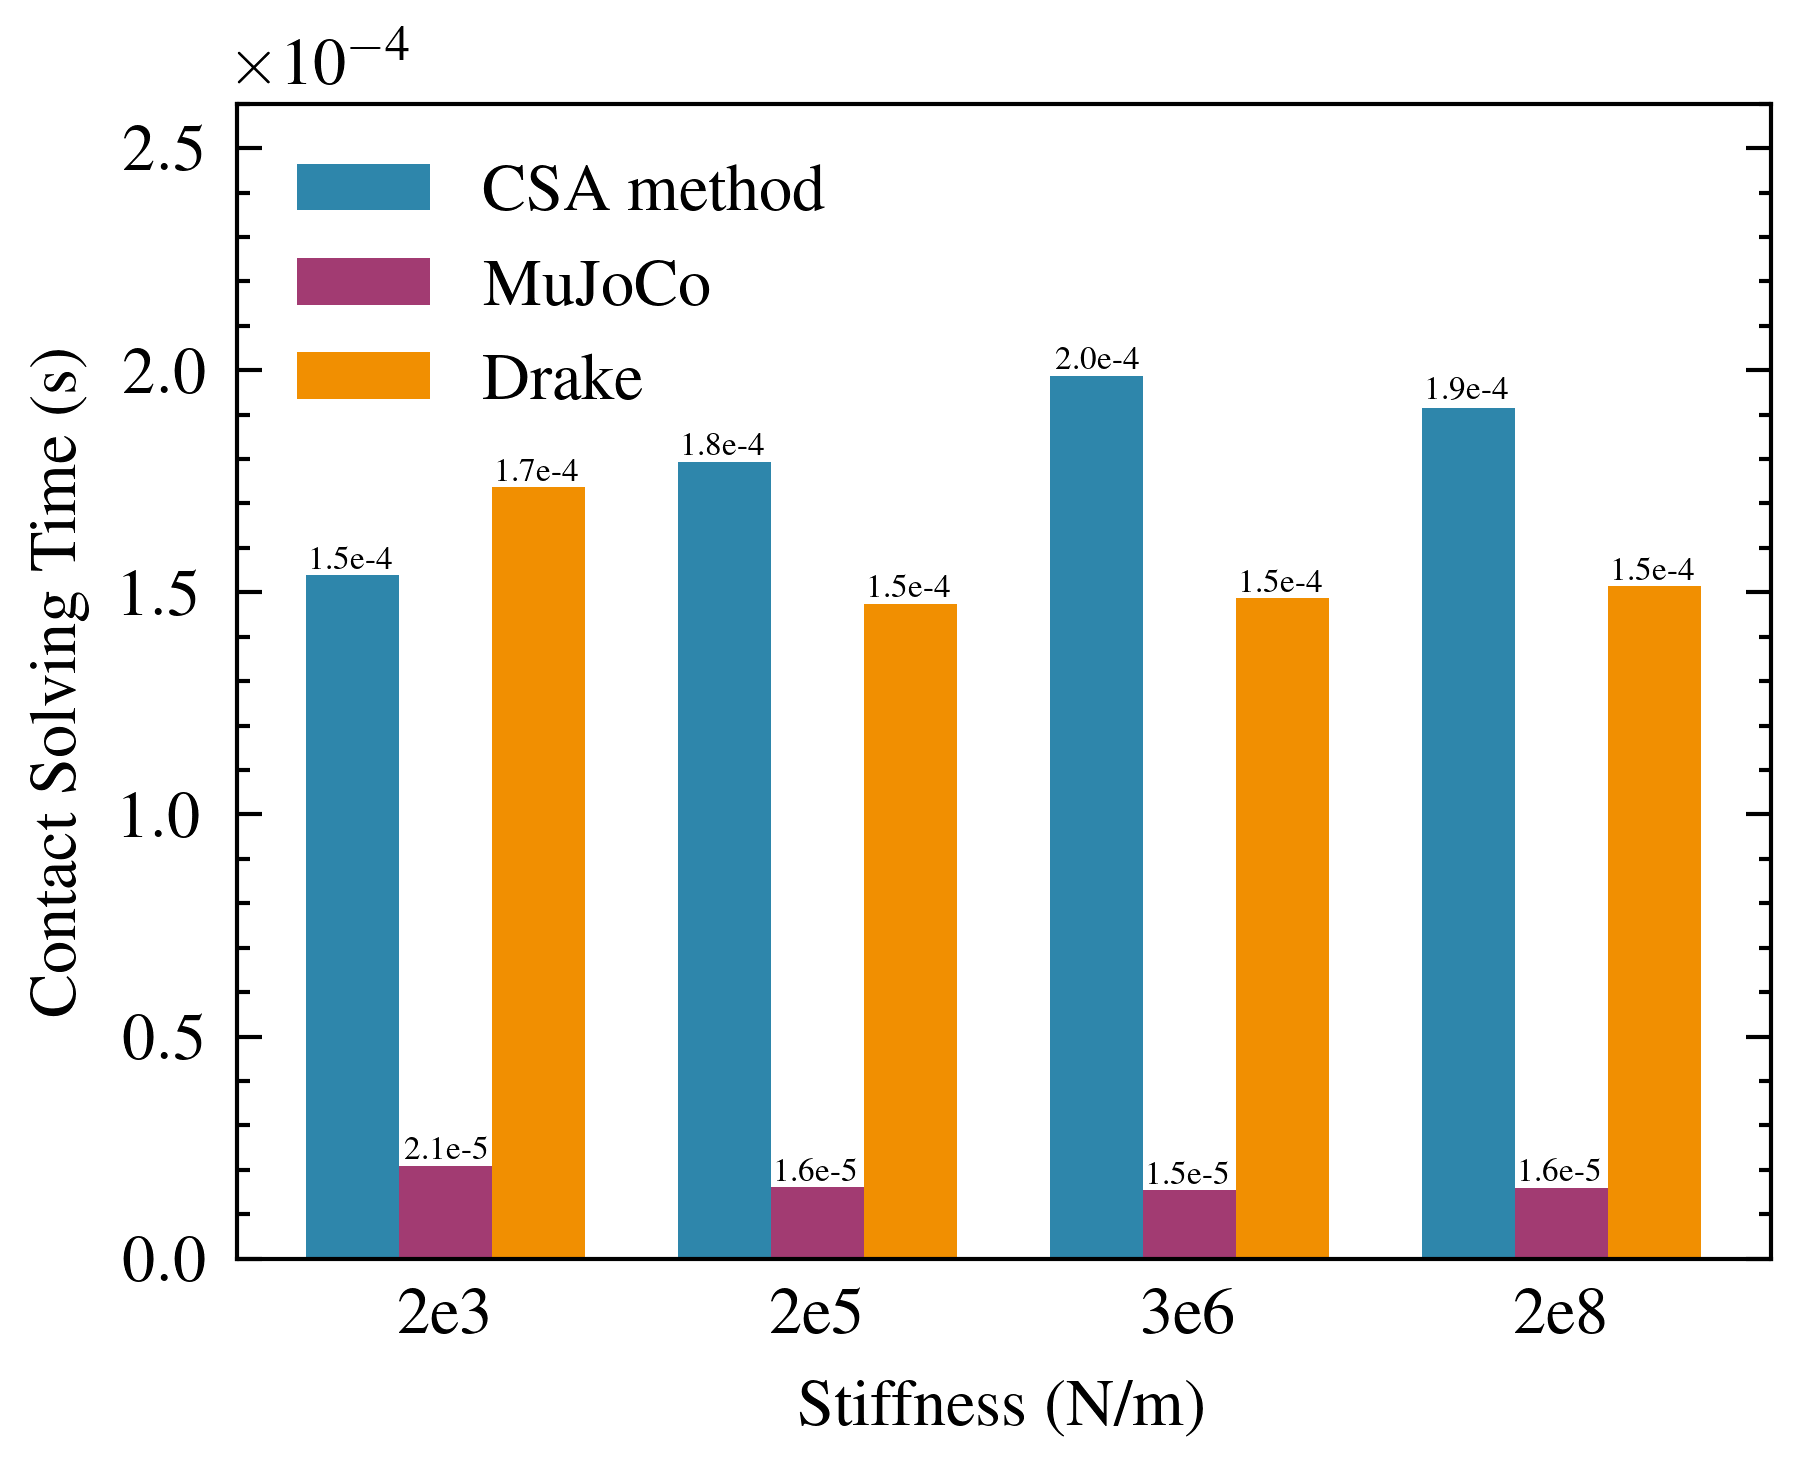

In [14]:
import numpy as np
from os.path import abspath
import os
import matplotlib.pyplot as plt
import scienceplots
perfDataPathSire = abspath(os.getcwd()) + "/sire/bouncing_ball/sire_perf_measure_contact.csv"
perfDataPathMujoco = abspath(os.getcwd()) + "/mujoco/bouncing_ball/mujoco_perf_measure_contact.csv"
perfDataPathDrake = abspath(os.getcwd()) + "/drake/bouncing_ball/drake_perf_measure_contact.csv"
# print(firstBouncingPathSire)
# print(firstBouncingPathMujoco)
# print(firstBouncingPathDrake)
perfDataSire = np.genfromtxt(perfDataPathSire, delimiter=',')
perfDataMujoco = np.genfromtxt(perfDataPathMujoco, delimiter=',')
perfDataDrake = np.genfromtxt(perfDataPathDrake, delimiter=',')
avgSire = np.sum(perfDataSire, 0) / perfDataSire.shape[0]
avgMujoco = np.sum(perfDataMujoco, 0) / perfDataMujoco.shape[0]
avgDrake = np.sum(perfDataDrake, 0) / perfDataDrake.shape[0]
print(avgSire)
print(avgMujoco)
print(avgDrake)
# 使用 SciencePlots 风格
# plt.style.use(['science', 'ieee', 'grid'])
with plt.style.context(['science','ieee']):
  # 参数标签（根据您之前提到的参数）
  parameters = ['2e3', '2e5', '3e6', '2e8']
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  # 设置图形
  # fig, ax = plt.subplots(figsize=(4, 4))
  fig, ax = plt.subplots()

  # 柱状图位置
  x = np.arange(len(parameters))
  width = 0.25

  # 绘制柱状图
  bars1 = ax.bar(x - width, avgSire, width, label='CSA method', color=scientific_colors[0])
  bars2 = ax.bar(x, avgMujoco, width, label='MuJoCo', color=scientific_colors[1])
  bars3 = ax.bar(x + width, avgDrake, width, label='Drake', color=scientific_colors[2])

  # 添加数值标签
  def add_value_labels(bars):
      for bar in bars:
          height = bar.get_height() 
          # height = bar.get_height() * 1.02
          ax.text(bar.get_x() + bar.get_width()/2., height,
                  f'{bar.get_height():.1e}'.replace("-0", "-"), ha='center', va='bottom', fontsize=4)

  add_value_labels(bars1)
  add_value_labels(bars2)
  add_value_labels(bars3)

  # 设置图表属性
  ax.set_xlabel('Stiffness (N/m)')
  ax.set_ylabel('Contact Solving Time (s)')
  # ax.set_title('Comparison of Simulation Platforms: Average Time for 10s Simulation', fontsize=13, pad=15)
  ax.set_xticks(x)
  ax.set_xticklabels(parameters)
  ax.legend()

  # 由于数值范围较大，可以考虑使用对数坐标
  # ax.set_yscale('log')
  ax.set_ylim(0, 0.00026)
  ax.set_ylabel('Contact Solving Time (s)')
  ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
  ax.tick_params(axis='x', which='both', 
               bottom=False,      # 禁用底部刻度
               top=False)         # 禁用顶部刻度  

  # 添加网格
  # ax.grid(True, alpha=0.3)

  # 调整布局
  # plt.tight_layout()

  plt.savefig('D:/papers/sire_contact_model/res/bouncing_ball_perf_compare_contact.pdf', format="pdf", dpi=300, bbox_inches='tight')
  plt.show()

# Bouncing Box Plots

d:\code\sire\demo\demo_paper/sire/bouncing_box/first_bouncing_data.csv
d:\code\sire\demo\demo_paper/mujoco/bouncing_box/first_bouncing_data.csv
d:\code\sire\demo\demo_paper/drake/bouncing_box/first_bouncing_data.csv


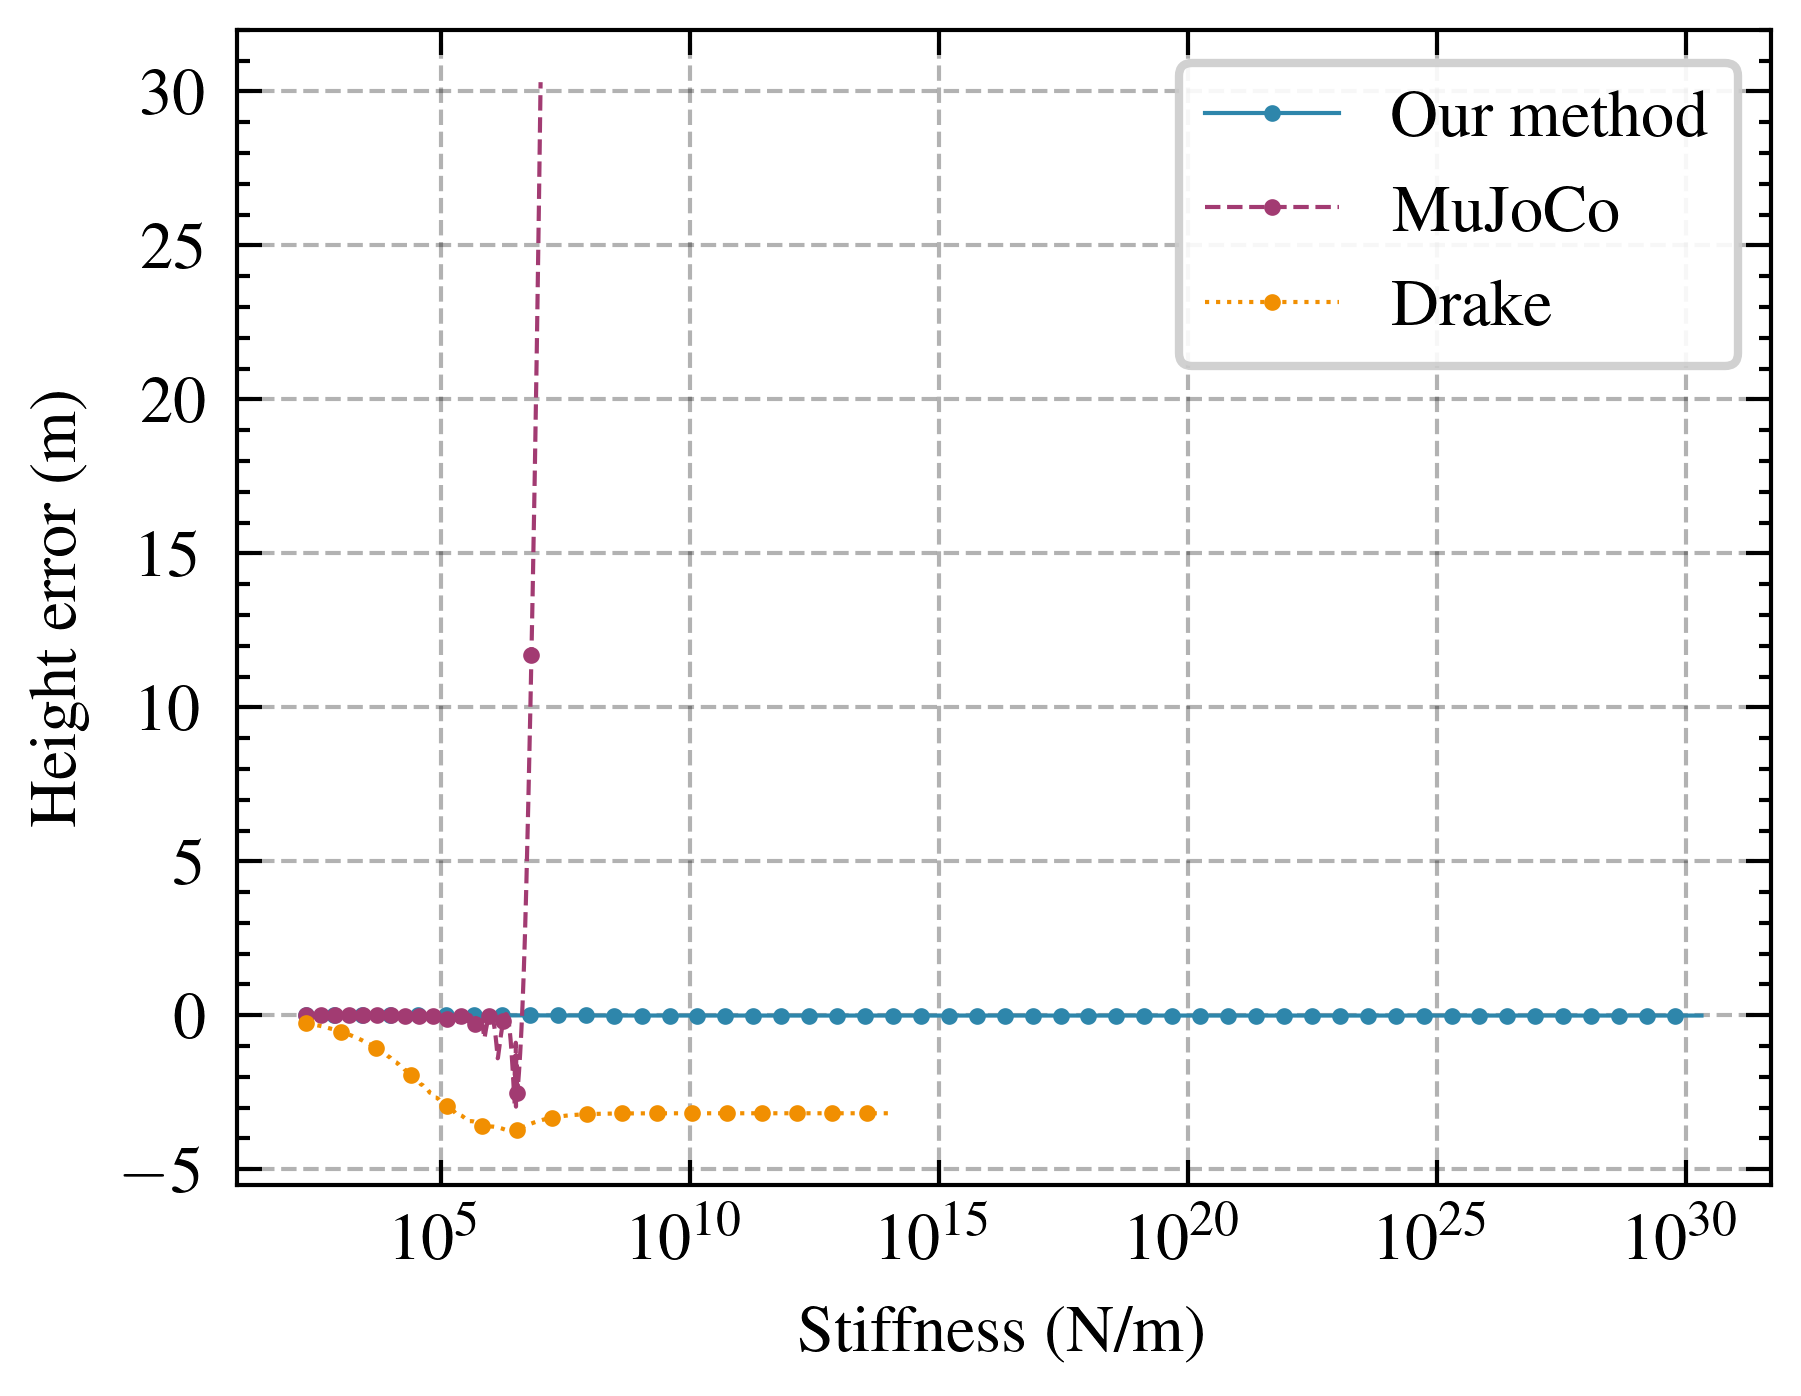

In [ ]:
import numpy as np
from os.path import abspath
import os
import matplotlib.pyplot as plt
import scienceplots

firstBouncingPathSire = abspath(os.getcwd()) + "/sire/bouncing_box/first_bouncing_data.csv"
firstBouncingPathMujoco = abspath(os.getcwd()) + "/mujoco/bouncing_box/first_bouncing_data.csv"
firstBouncingPathDrake = abspath(os.getcwd()) + "/drake/bouncing_box/first_bouncing_data.csv"
print(firstBouncingPathSire)
print(firstBouncingPathMujoco)
print(firstBouncingPathDrake)
firstBouncingDataSire = np.genfromtxt(firstBouncingPathSire, delimiter=',', skip_header=1)
firstBouncingDataMujoco = np.genfromtxt(firstBouncingPathMujoco, delimiter=',', skip_header=1)
firstBouncingDataDrake = np.genfromtxt(firstBouncingPathDrake, delimiter=',', skip_header=1)

with plt.style.context(['science','ieee', 'grid']):
  legendStrs = []
  linestyles = ["-", ":", "--", "-."]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  markevery=20
  markersize=1
  linewidth=0.5
  marker='o'
  plt.semilogx(firstBouncingDataSire[:, 0], firstBouncingDataSire[:, 1], label="Our solver", marker=marker, markevery=markevery, markersize=markersize, linewidth=linewidth, color=scientific_colors[0])
  plt.semilogx(firstBouncingDataMujoco[:, 0], firstBouncingDataMujoco[:, 1], label="MuJoCo", marker=marker, markevery=markevery * 3, markersize=markersize, linewidth=linewidth, color=scientific_colors[1])
  plt.semilogx(firstBouncingDataDrake[:, 0], firstBouncingDataDrake[:, 1], label="Drake", marker=marker, markevery=markevery * 3, markersize=markersize, linewidth=linewidth, color=scientific_colors[2])
  # plt.legend(loc="best", fontsize=8)
  plt.legend(framealpha=0.9, loc="upper right")
  # plt.ylim(top=5.5, bottom=-0.5)
  plt.ylabel(r'Height error (m)')
  plt.grid(True, linestyle='--', alpha=0.3)
  plt.xlabel(r'Stiffness (N/m)')
  # plt.title('Bouncing ball by proposed method')
  # plt.grid(True, alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

In [1]:
def binarySearch(timeIndices, time):
  import math
  """
  Binary search to find the index of the closest time
  :param timeIndices: list of time indices
  :param time: target time
  :return: index of the closest time index
  """
  low = 0
  high = len(timeIndices) - 1
  while low < high:
    mid = (low + high) // 2
    # print(low, mid, high, timeIndices[low], timeIndices[mid], timeIndices[high])
    if high - low <= 1:
      return low
    if timeIndices[mid] < time:
      low = mid
    else:
      high = mid
    

def selectXRange(xLower, xUpper, yLower, yUpper, x, y):
  import numpy as np
  # totalFrameNumber = int((max - min) * frameRate)
  xStartIdx = binarySearch(x, xLower)
  xEndIdx = binarySearch(x, xUpper) + 1
  n = xEndIdx - xStartIdx
  resultx = []
  resulty = []

  for i in range(n):
    # currentX = min + i / frameRate
    # currentIdx = binarySearch(x, currentX)
    idx = xStartIdx + i
    if y[idx] >= yLower and y[idx] <= yUpper:
      resultx.append(x[idx])
      resulty.append(y[idx])
  return resultx, resulty

# print(binarySearch(firstBouncingDataDrake[:, 0], 5e6))

[np.float64(4685358.6728376215), np.float64(4736379.756108085), np.float64(4787956.432049219), np.float64(4840094.750772004), np.float64(4892800.828269911), np.float64(4946080.847136377), np.float64(4999941.057290011), np.float64(5054387.776707738), np.float64(5109427.392165914), np.float64(5165066.359989524), np.float64(5221311.20680952), np.float64(5278168.530328424), np.float64(5335645.000094254), np.float64(5393747.3582828995), np.float64(5452482.420488954)]
[np.float64(5.796944033460345), np.float64(6.030435030089764), np.float64(6.271149937834566), np.float64(6.519270583298278), np.float64(6.774982433179152), np.float64(7.038476481816913), np.float64(7.309945655896452), np.float64(7.589588431119475), np.float64(7.877608295480462), np.float64(8.17421429702943), np.float64(8.478004608558098), np.float64(8.785266719437802), np.float64(9.095874752548847), np.float64(9.409865143218504), np.float64(9.727274723535553)]


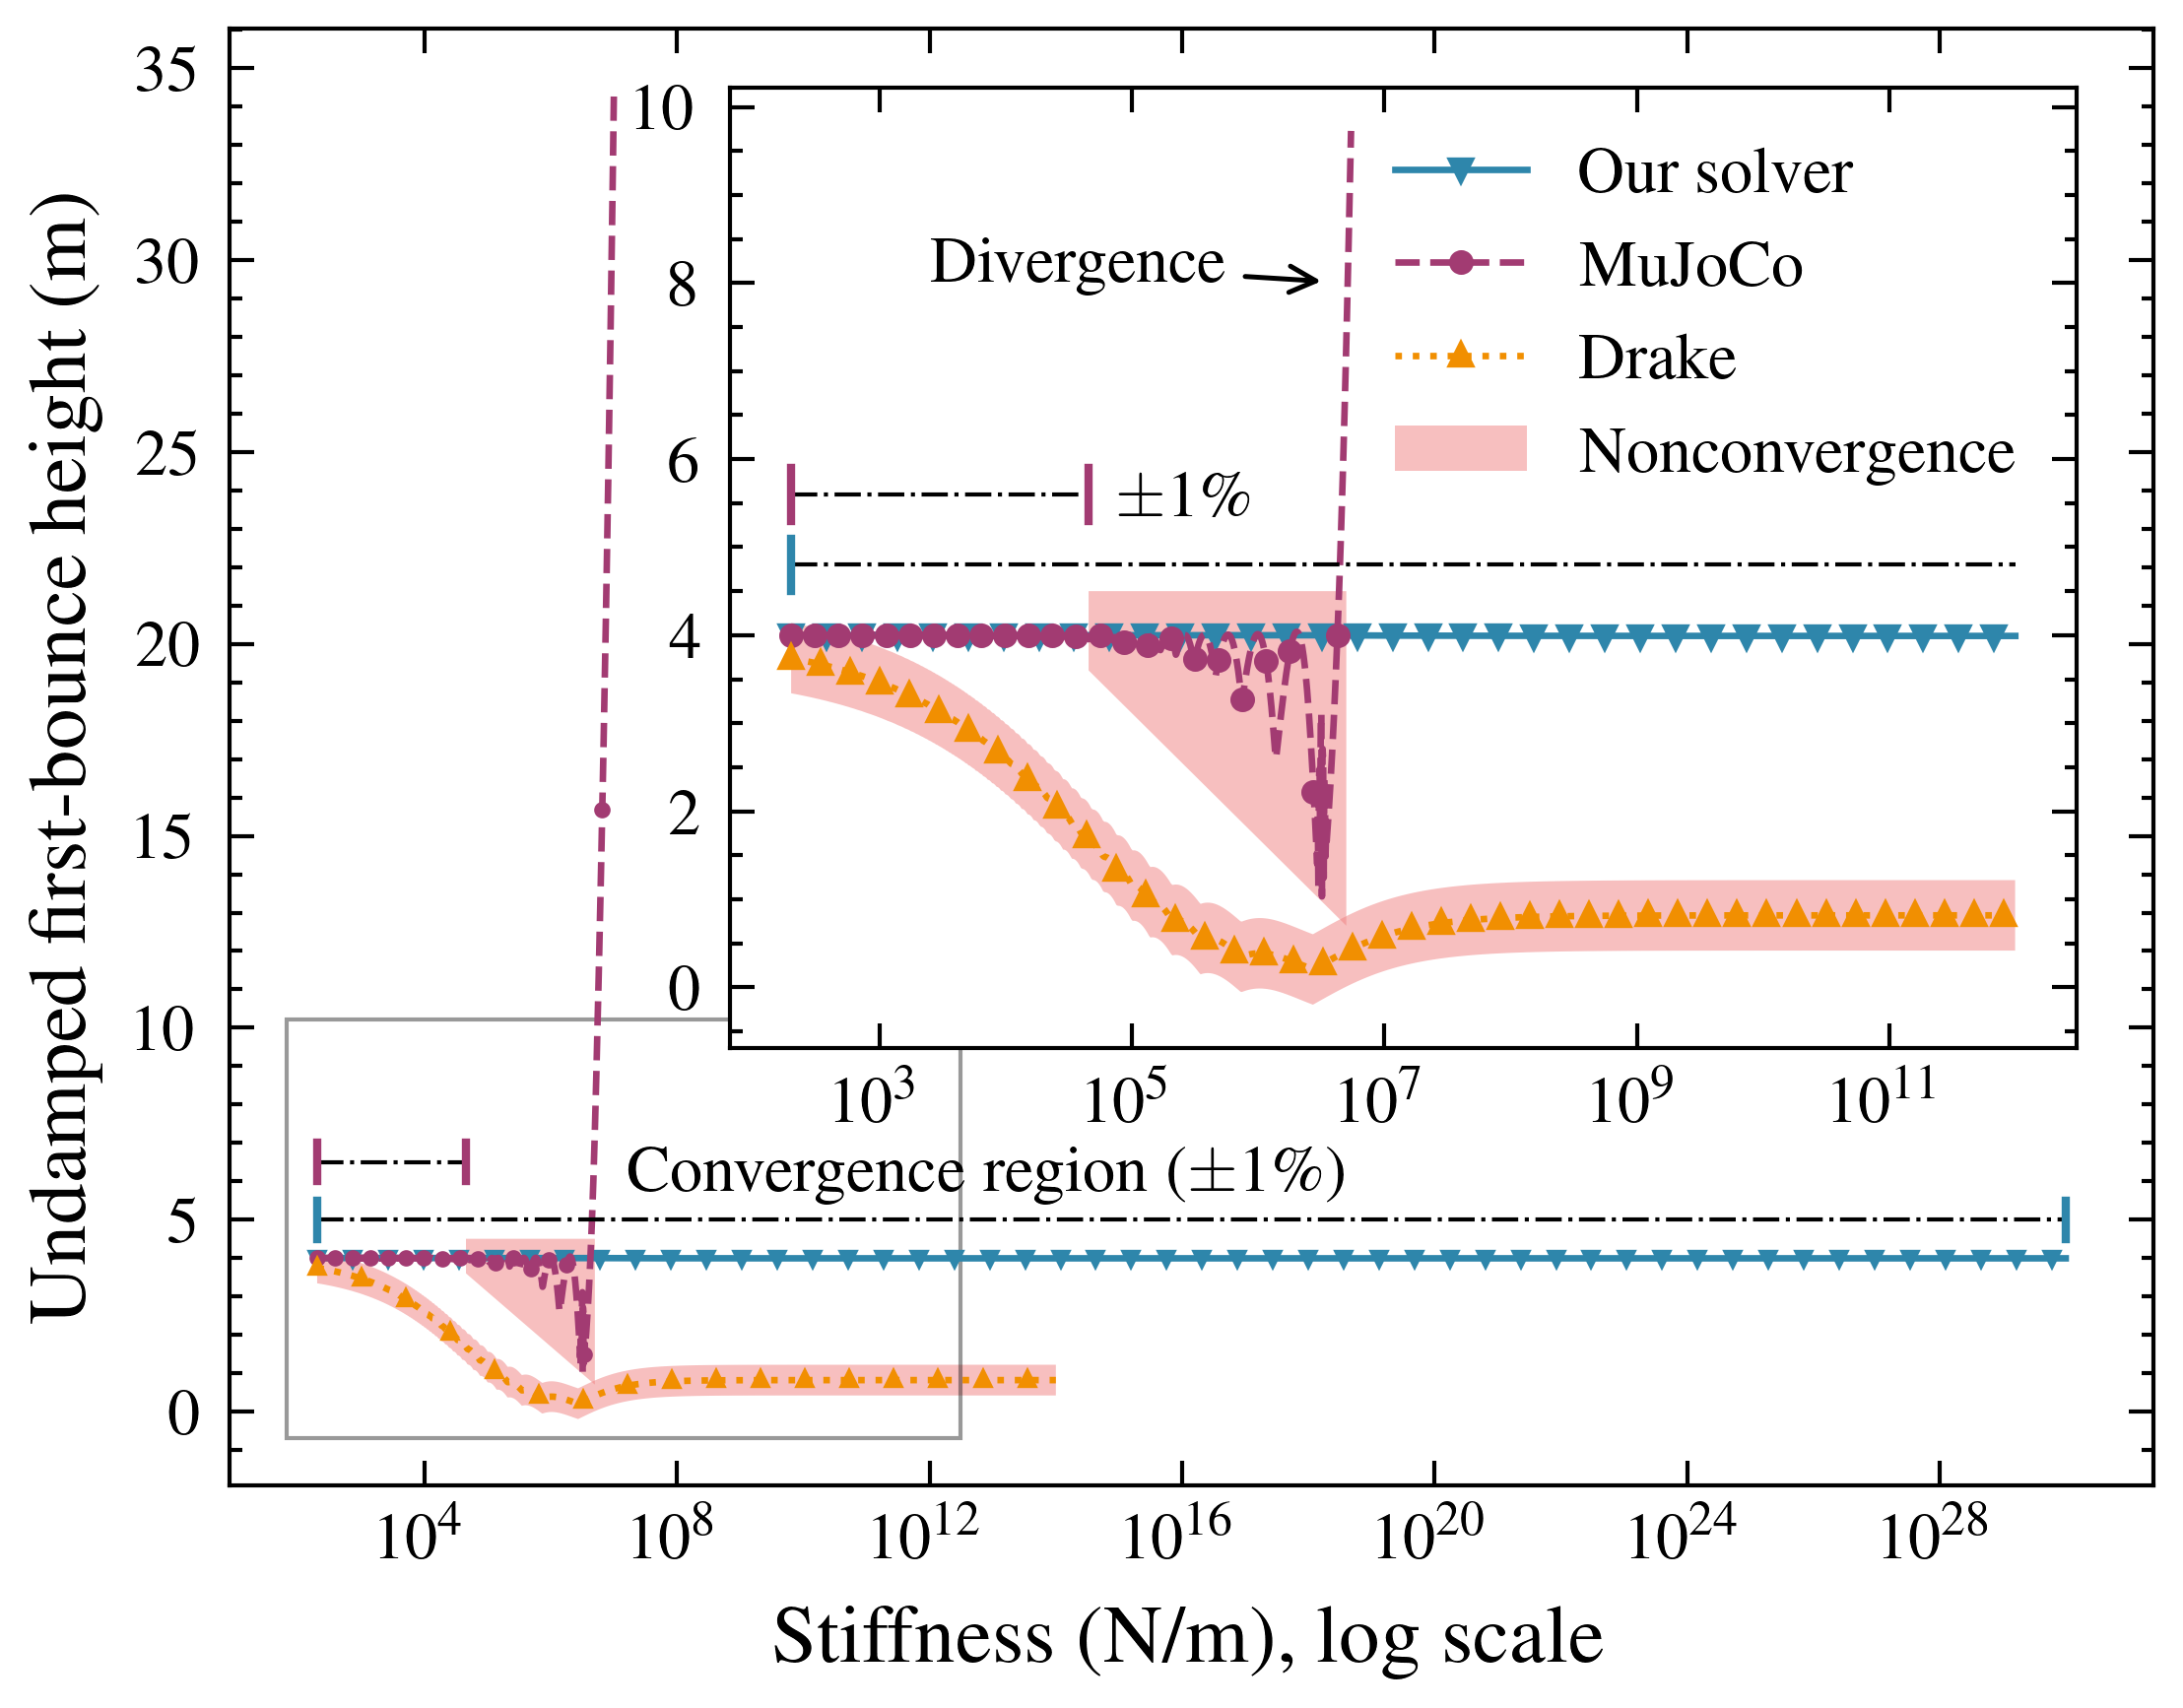

In [3]:
import numpy as np
from os.path import abspath
import os
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.patches import Rectangle
from matplotlib.patches import Polygon
from matplotlib.ticker import LogLocator

def plotBracket(ax, x_left, x_right, y_bracket, cap_height, color, linestyle="-.", linewidth=0.5):
  # horizontal line
  ax.plot([x_left, x_right], [y_bracket, y_bracket], linestyle=linestyle,
          color="black", linewidth=linewidth)

  # left cap
  ax.plot([x_left, x_left],
          [y_bracket - cap_height/2, y_bracket + cap_height/2],
          color=color, linewidth=1, linestyle="-")

  # right cap
  ax.plot([x_right, x_right],
          [y_bracket - cap_height/2, y_bracket + cap_height/2],
          color=color, linewidth=1, linestyle="-")

firstBouncingPathSire = abspath(os.getcwd()) + "/sire/bouncing_box/first_bouncing_data.csv"
firstBouncingPathMujoco = abspath(os.getcwd()) + "/mujoco/bouncing_box/first_bouncing_data.csv"
firstBouncingPathDrake = abspath(os.getcwd()) + "/drake/bouncing_box/first_bouncing_data.csv"
# print(firstBouncingPathSire)
# print(firstBouncingPathMujoco)
# print(firstBouncingPathDrake)
releaseHeight = 4
convergeRate = 0.01
errorBound = releaseHeight * convergeRate
convergeRegion = [releaseHeight - errorBound, releaseHeight + errorBound]
firstBouncingDataSire = np.genfromtxt(firstBouncingPathSire, delimiter=',', skip_header=1)
firstBouncingDataMujoco = np.genfromtxt(firstBouncingPathMujoco, delimiter=',', skip_header=1)
firstBouncingDataDrake = np.genfromtxt(firstBouncingPathDrake, delimiter=',', skip_header=1)
firstBouncingDataSire[:, 1] = firstBouncingDataSire[:, 1] + 4
firstBouncingDataMujoco[:, 1] = firstBouncingDataMujoco[:, 1] + 4
firstBouncingDataDrake[:, 1] = firstBouncingDataDrake[:, 1] + 4

with plt.style.context(['science','ieee']):
  fig, ax = plt.subplots(figsize=(4.2, 3.2))
  # fig, ax = plt.subplots(figsize=(4, 4))
  legendStrs = []
  linestyles = ["-", ":", "--", "-."]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  markevery=20
  markersize=1
  linewidth=0.8
  marker = ['v', 'o', '^']
  selectedDataSireX, selectedDataSireY = selectXRange(0, 1e30, -10, 10, firstBouncingDataSire[:, 0], firstBouncingDataSire[:, 1])
  ax.semilogx(selectedDataSireX, selectedDataSireY, label="Our solver", marker=marker[0], markevery=markevery, markersize=markersize, linewidth=linewidth, color=scientific_colors[0])
  ax.semilogx(firstBouncingDataMujoco[:, 0], firstBouncingDataMujoco[:, 1], label="MuJoCo", marker=marker[1], markevery=markevery * 3, markersize=markersize, linewidth=linewidth, color=scientific_colors[1])
  ax.semilogx(firstBouncingDataDrake[:, 0], firstBouncingDataDrake[:, 1], label="Drake", marker=marker[2], markevery=markevery * 3, markersize=markersize, linewidth=linewidth, color=scientific_colors[2])
  band_width = 0.4
  ax.fill_between(firstBouncingDataDrake[:, 0], 
                   (firstBouncingDataDrake[:, 1] - band_width).tolist(),
                   (firstBouncingDataDrake[:, 1] + band_width).tolist(),
                   alpha=0.5, color='lightcoral',
                   edgecolor='none', zorder=1)  # zorder 确保在曲线下方
  # Convergence region for Expo
  x_left  = 2e2
  x_right = 1e30
  y_bracket = 5
  cap_height = 1   # 竖线高度
  x_text = (x_left * x_right) ** 0.4  # log-scale center
  ax.text(x_text, y_bracket + 0.4,
        r'Convergence region ($\pm1\%$)',
        ha='center', va='bottom')
  plotBracket(ax, x_left, x_right, y_bracket, cap_height, scientific_colors[0])
  x_left  = 2e2
  x_right = firstBouncingDataMujoco[:, 0][abs(firstBouncingDataMujoco[:, 1] - 4) > errorBound][0]
  y_bracket = 6.5
  cap_height = 1   # 竖线高度
  plotBracket(ax, x_left, x_right, y_bracket, cap_height, scientific_colors[1])
  # x_left  = 1e2
  # x_right = 1e2
  # y_bracket = 6.8
  # cap_height = 1   # 竖线高度
  # plotBracket(ax, x_left, x_right, y_bracket, cap_height, scientific_colors[2])

  ax.set_ylabel(r'Undamped first-bounce height (m)', fontsize=10)
  ax.set_xlabel(r'Stiffness (N/m), log scale', fontsize=10)
  from mpl_toolkits.axes_grid1.inset_locator import inset_axes
  from mpl_toolkits.axes_grid1.inset_locator import mark_inset
  axins = ax.inset_axes((0.26, 0.30, 0.7, 0.66))
  # axins = ax.inset_axes((0.22, 0.33, 0.73, 0.62))
  xStart = 0
  xEnd = 1e12
  yStart = -1
  yEnd = 10
  selectedDataSireX, selectedDataSireY = selectXRange(xStart, xEnd, yStart, yEnd, firstBouncingDataSire[:, 0], firstBouncingDataSire[:, 1])
  selectedDataMujocoX, selectedDataMujocoY = selectXRange(xStart, xEnd, yStart, yEnd, firstBouncingDataMujoco[:, 0], firstBouncingDataMujoco[:, 1])
  selectedDataDrakeX, selectedDataDrakeY = selectXRange(xStart, xEnd, yStart, yEnd, firstBouncingDataDrake[:, 0], firstBouncingDataDrake[:, 1])
  
  axins.semilogx(selectedDataSireX, selectedDataSireY, marker=marker[0], label="Our solver", markersize=2, markevery=10, linewidth=linewidth, color=scientific_colors[0])
  axins.semilogx(selectedDataMujocoX, selectedDataMujocoY, marker=marker[1], label="MuJoCo", markersize=2, markevery=markevery*2, linewidth=linewidth, color=scientific_colors[1])
  axins.semilogx(selectedDataDrakeX, selectedDataDrakeY, marker=marker[2], label="Drake", markersize=2, markevery=markevery, linewidth=linewidth, color=scientific_colors[2])
  # axins.xaxis.set_minor_locator(LogLocator(base=10, subs='all', numticks=10))
  print(selectedDataMujocoX[-15:])
  print(selectedDataMujocoY[-15:])
  linewidth = 0.6
  # 绘制连接线
  connector_x = 3172565.4483902846
  connector_y = 8.019902009898534
  text_x = connector_x - 3.17e6
  text_y = connector_y
  axins.annotate(
      'Divergence', 
      xycoords='data',
      xy=(connector_x, connector_y), 
      xytext=(text_x, text_y),
      arrowprops=dict(
          arrowstyle='->',
          color="black",
          lw=linewidth,
          shrinkA=0,
          shrinkB=0
      )
  )
  band_width = 0.4
  axins.fill_between(selectedDataDrakeX, 
                   (np.array(selectedDataDrakeY) - band_width).tolist(),
                   (np.array(selectedDataDrakeY) + band_width).tolist(),
                   alpha=0.5, color='lightcoral',
                   edgecolor='none', zorder=1)  # zorder 确保在曲线下方
  x_left  = 2e2
  x_right = 1e12
  y_bracket = 4.8
  cap_height = 0.6   # 竖线高度
  x_text = (x_left * x_right) ** 0.38  # log-scale center
  axins.text(x_text, y_bracket + 0.45,
        r'$\pm1\%$',
        ha='center', va='bottom')
  # horizontal line
  axins.plot([x_left, x_right], [y_bracket, y_bracket], linestyle="-.",
          color="black", linewidth=0.5)
  # left cap
  axins.plot([x_left, x_left],
          [y_bracket - cap_height/2, y_bracket + cap_height/2],
          color=scientific_colors[0], linewidth=1, linestyle="-")
  
  rect_low_x, rect_high_x = firstBouncingDataMujoco[:, 0][abs(firstBouncingDataMujoco[:, 1] - 4) > errorBound][0], 5e6
  rect_low_y, rect_high_y = 0.7, 4.5

  rect_width = rect_high_x - rect_low_x
  rect_height = rect_high_y - rect_low_y
  vertices = np.array([
      [rect_low_x, 3.6],  # 左下角 (下底左端点)
      [rect_high_x, rect_low_y],  # 右下角 (下底右端点)
      [rect_high_x, rect_high_y],  # 右上角 (上底右端点)
      [rect_low_x, rect_high_y]   # 左上角 (上底左端点)
  ])

  # 2. 创建并添加梯形补丁
  trapezoid = Polygon(
      vertices,
      closed=True,          # 确保图形是闭合的
      facecolor='lightcoral',  # 填充颜色
      alpha=0.5,           # 透明度
      label='Nonconvergence'
  )
  axins.add_patch(trapezoid)
  trapezoid = Polygon(
      vertices,
      closed=True,          # 确保图形是闭合的
      facecolor='lightcoral',  # 填充颜色
      alpha=0.5,           # 透明度
  )
  ax.add_patch(trapezoid)
  x_left  = 2e2
  x_right = firstBouncingDataMujoco[:, 0][abs(firstBouncingDataMujoco[:, 1] - 4) > errorBound][0]
  y_bracket = 5.6
  cap_height = 0.6   # 竖线高度
  plotBracket(axins, x_left, x_right, y_bracket, cap_height, scientific_colors[1])
  # axins.axvline (x=rect_low_x, ymin=0, ymax=0.5, color="black", linestyle=':', linewidth=0.6)
  # 2. 在坐标轴上添加标记（一个小刻度或三角形）
  # axins.plot([rect_low_x], [ax.get_ylim()[0]], marker='^', color='darkred', markersize=10, clip_on=False)
  # from matplotlib.ticker import FixedLocator
  # desired_ticks = [1e3, rect_low_x, 1e7, 1e10]
  # axins.xaxis.set_major_locator(FixedLocator(desired_ticks))
  handles, labels = axins.get_legend_handles_labels()
  # labels[0] = r'$\it{Expo}$' 
  axins.legend(handles, labels, framealpha=0.9, loc="upper right")
  # axins.plot(x4, y4, marker='o', markersize=2, linewidth=0.5, linestyle='-.')
  # axins.tick_params(axis='x', bottom=True, top=True, labelbottom=False, labeltop=True)
  # axins.axhline(y=0, linewidth=0.5)
  pp, p1, p2 = mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec='k', lw=0.5, alpha=0.5)
  pp.set_alpha(0.4)
  p1.set_alpha(0)
  p2.set_alpha(0)
  plt.savefig("D:/papers/sire_contact_model/res/bouncing_box_stiffness_range.pdf", format="pdf", dpi=600, bbox_inches='tight')
  plt.show()

## Performance Plots

In [ ]:
import numpy as np
from os.path import abspath
import os
import matplotlib.pyplot as plt
import scienceplots
perfDataPathSire = abspath(os.getcwd()) + "/sire/bouncing_box/sire_perf_measure_contact.csv"
perfDataPathMujoco = abspath(os.getcwd()) + "/mujoco/bouncing_box/mujoco_perf_measure_contact.csv"
perfDataPathDrake = abspath(os.getcwd()) + "/drake/bouncing_box/drake_perf_measure_contact.csv"
# print(firstBouncingPathSire)
# print(firstBouncingPathMujoco)
# print(firstBouncingPathDrake)
perfDataSire = np.genfromtxt(perfDataPathSire, delimiter=',')
perfDataMujoco = np.genfromtxt(perfDataPathMujoco, delimiter=',')
perfDataDrake = np.genfromtxt(perfDataPathDrake, delimiter=',')
avgSire = np.sum(perfDataSire, 0) / perfDataSire.shape[0]
avgMujoco = np.sum(perfDataMujoco, 0) / perfDataMujoco.shape[0]
avgDrake = np.sum(perfDataDrake, 0) / perfDataDrake.shape[0]
print(avgSire)
print(avgMujoco)
print(avgDrake)
# 使用 SciencePlots 风格
# plt.style.use(['science', 'ieee', 'grid'])
with plt.style.context(['science','ieee', 'grid']):
  # 参数标签（根据您之前提到的参数）
  parameters = ['2e3', '2e5', '3e6', '2e8']
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  # 设置图形
  fig, ax = plt.subplots(figsize=(4, 4))

  # 柱状图位置
  x = np.arange(len(parameters))
  width = 0.25

  # 绘制柱状图
  bars1 = ax.bar(x - width, avgSire, width, label='Our solver', color=scientific_colors[0])
  bars2 = ax.bar(x, avgMujoco, width, label='MuJoCo', color=scientific_colors[1])
  bars3 = ax.bar(x + width, avgDrake, width, label='Drake', color=scientific_colors[2])

  # 添加数值标签
  def add_value_labels(bars):
      for bar in bars:
          # height = bar.get_height() + 0.01
          height = bar.get_height() * 1.02
          ax.text(bar.get_x() + bar.get_width()/2., height,
                  f'{height:.3f}', ha='center', va='bottom', fontsize=6)

  add_value_labels(bars1)
  add_value_labels(bars2)
  add_value_labels(bars3)

  # 设置图表属性
  ax.set_xlabel('Stiffness (N/m)')
  ax.set_ylabel('Average Simulation Time (s)')
  # ax.set_title('Comparison of Simulation Platforms: Average Time for 10s Simulation', fontsize=13, pad=15)
  ax.set_xticks(x)
  ax.set_xticklabels(parameters)
  ax.legend()

  # 由于数值范围较大，可以考虑使用对数坐标
  ax.set_yscale('log')
  ax.set_ylabel('Average Simulation Time (s) - Log Scale')

  # 添加网格
  ax.grid(True, alpha=0.3)

  # 调整布局
  # plt.tight_layout()

  plt.savefig('D:/papers/sire_contact_model/res/bouncing_box_perf_compare.pdf', format="pdf", dpi=300, bbox_inches='tight')
  plt.show()

FileNotFoundError: d:\code\sire\demo\demo_paper/sire/bouncing_box/sire_perf_measure_contact.csv not found.

In [8]:
import numpy as np
from os.path import abspath
import os
import matplotlib.pyplot as plt
import scienceplots

bodyHeightsPath = abspath(os.getcwd()) + "/sire/dog/body_height.csv"
bodyHeightsTime = np.genfromtxt(bodyHeightsPath, delimiter=',', skip_header=0)
time = bodyHeightsTime[:, 0]
bodyHeights = bodyHeightsTime[:, 1]

bodyHeightsPath = abspath(os.getcwd()) + "/mujoco/dog/body_height.csv"
bodyHeightsTime = np.genfromtxt(bodyHeightsPath, delimiter=',', skip_header=0)
mTime = bodyHeightsTime[:, 0]
mBodyHeights = bodyHeightsTime[:, 1]

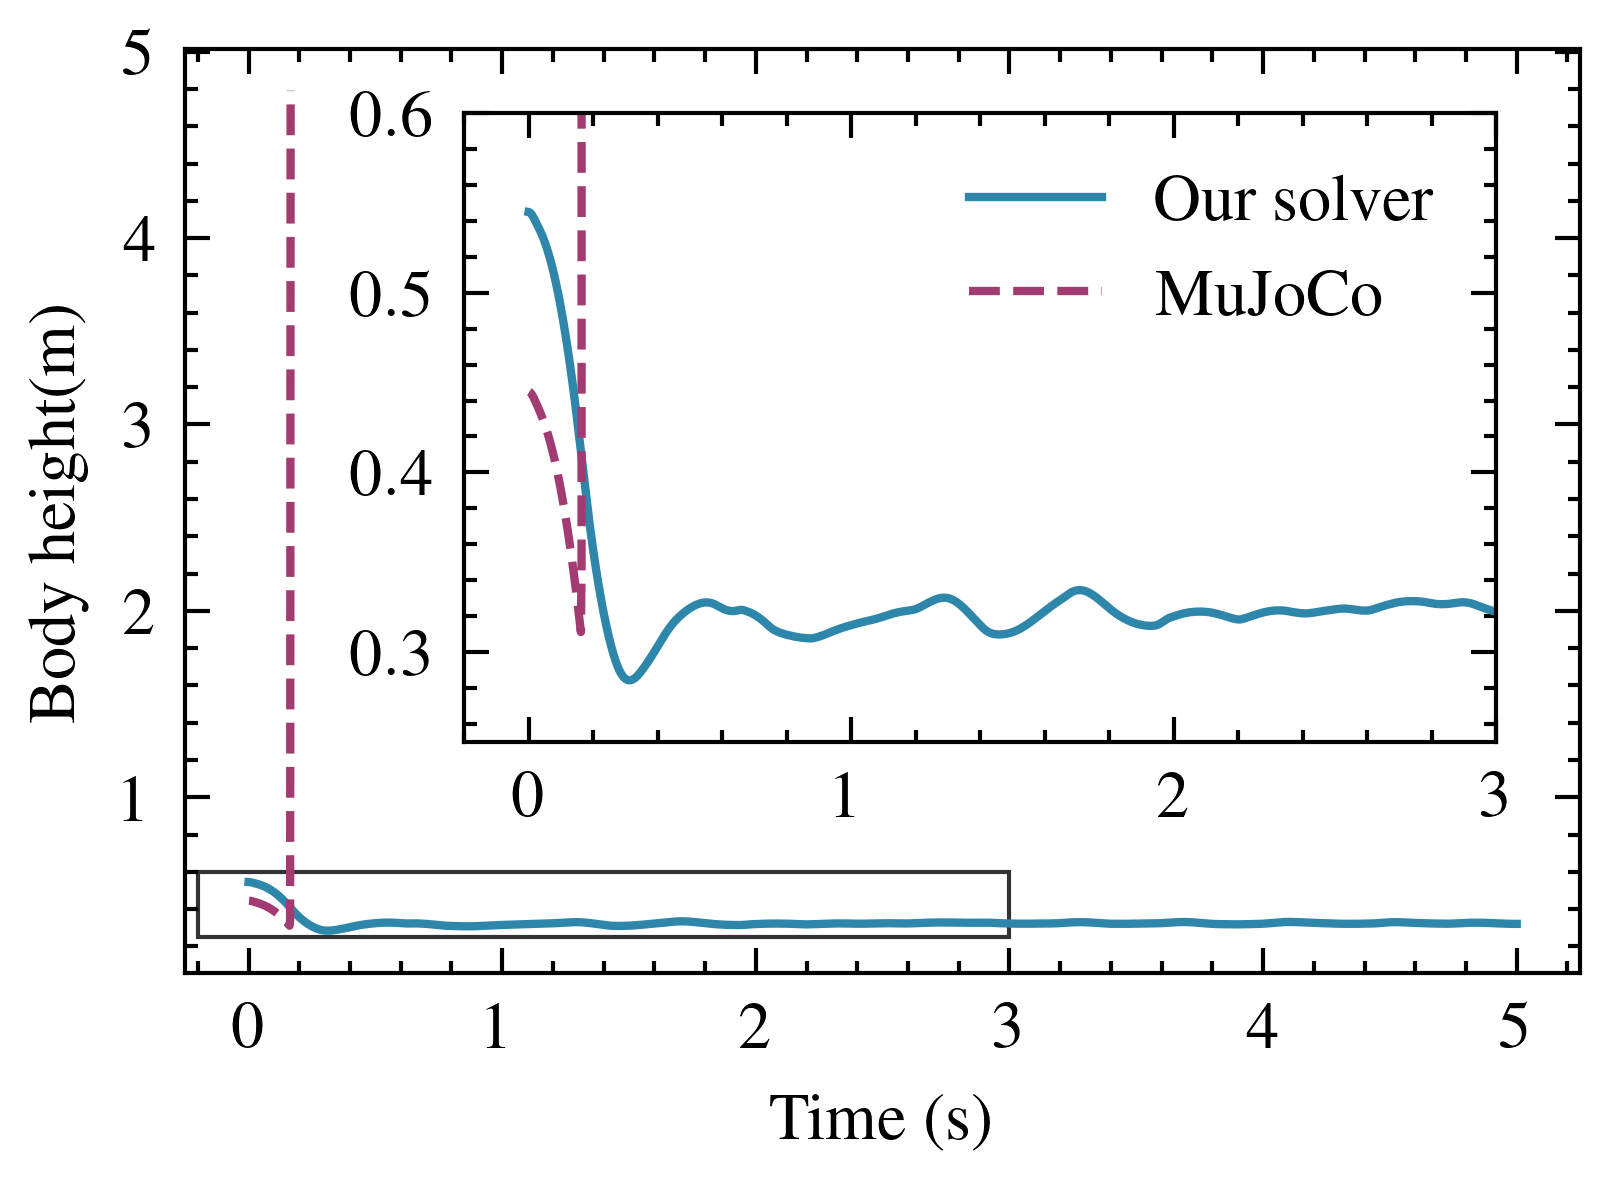

In [9]:

with plt.style.context(['science','ieee']):
  fig, ax = plt.subplots(figsize=(3, 2))
  legendStrs = []
  linestyles = ["-", ":", "--", "-."]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  markevery=20
  markersize=1
  linewidth=1
  marker='o'
  # ax.plot(bodyHeights[:, 0], bodyHeights[:, 1], label="Expo", marker=marker, markevery=markevery, markersize=markersize, linewidth=linewidth, color=scientific_colors[0])
  ax.plot(time, bodyHeights, label="Our solver", linewidth=linewidth, color=scientific_colors[0])
  # ax.plot(mTime, mBodyHeights, label="MuJoCo", marker=marker, markevery=markevery, markersize=markersize, linewidth=linewidth, color=scientific_colors[0])
  ax.plot(mTime, mBodyHeights, label="MuJoCo", linewidth=linewidth, color=scientific_colors[1])
  from mpl_toolkits.axes_grid1.inset_locator import inset_axes
  from mpl_toolkits.axes_grid1.inset_locator import mark_inset
  axins = ax.inset_axes((0.2, 0.25, 0.74, 0.68))
  # axins = ax.inset_axes((0.22, 0.33, 0.73, 0.62))
  # selectedDataMuJoX, selectedDataMuJoY = selectXRange(xStart, xEnd, yStart, yEnd, mTime, mBodyHeights)
  axins.plot(time, bodyHeights, label="Our solver", linewidth=linewidth, color=scientific_colors[0])
  axins.plot(mTime, mBodyHeights, label="Our solver", linewidth=linewidth, color=scientific_colors[1])
  axins.set_ylim([0.25, 0.6])
  axins.set_xlim([-0.2, 3])
  
  axins.legend(handles, labels, framealpha=0.9, loc="upper right")
  # axins.plot(x4, y4, marker='o', markersize=2, linewidth=0.5, linestyle='-.')
  # axins.tick_params(axis='x', bottom=True, top=True, labelbottom=False, labeltop=True)
  # axins.axhline(y=0, linewidth=0.5)
  pp, p1, p2 = mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec='k', lw=0.5, alpha=0.5)
  pp.set_alpha(0.8)
  # p1.set_alpha(0.6)
  # p2.set_alpha(0.6)
  p1.set_alpha(0)
  p2.set_alpha(0)
  handles, labels = ax.get_legend_handles_labels()
  # labels[0] = r'$\it{Expo}$' 
  # plt.legend(loc="best", fontsize=8)
  # ax.legend(framealpha=0.9, loc="upper right")
  # plt.ylim(top=5.5, bottom=-0.5)
  ax.set_ylabel(r'Body height(m)')
  # ax.grid(True, linestyle='--', alpha=0.3)
  ax.set_xlabel(r'Time (s)')
  # plt.title('Bouncing ball by proposed method')
  # plt.grid(True, alpha=0.3)
  plt.savefig("D:/papers/sire_contact_model/res/dog_body_height.pdf", format="pdf", dpi=600, bbox_inches='tight')
  plt.show()